# DBSCAN-only analysis of firearm-homicide records

## Purpose

This notebook documents the **DBSCAN-only configuration** evaluated in the paper. DBSCAN is applied to standardized spatial, temporal, and demographic features. One resulting DBSCAN cluster is then examined cartographically in Iztapalapa and expanded through two separate exploratory procedures: point-level distance/poverty grouping and AGEB-level Queen contiguity.

The workflow has five layers:

1. **Data preprocessing:** clean incident records, restrict the nominal study period to 2017–2022, and derive clustering features.
2. **DBSCAN:** standardize five variables, inspect a k-distance curve, and compare three `eps` values.
3. **Cluster characterization:** select one DBSCAN label and summarize its year, sex, age group, coordinates, and AGEB poverty context.
4. **Point-level spatial grouping:** choose seeds and expand groups using geodesic distance and equal poverty categories.
5. **Polygon-level extension:** propagate each group to neighbouring AGEB polygons with Queen contiguity when poverty categories match.

> **Scope note.** DBSCAN produces the labels stored in `cluster1`, `cluster2`, and `cluster3`. The six later `newgroup` assignments and Queen-neighbour expansions are custom cartographic post-processing; they are not additional DBSCAN clusters.

## Saved execution

| Quantity | Stored value |
|---|---:|
| Loaded homicide records | 4,021 |
| Records represented by the selected DBSCAN run | 3,979 |
| Candidate `eps` values | 0.40, 0.45, 0.50 |
| Selected DBSCAN result | `eps=0.50`, `min_samples=5` |
| Labels including noise | 32 |
| Manually selected DBSCAN label | 10 (31 records) |
| Selected-cluster profile | 2020; 100% female; 100% labelled 19–64 |
| Points retained inside Iztapalapa with AGEB data | 23 |
| Silhouette excluding noise | 0.943759 |
| Silhouette including noise | 0.829865 |

## Reproducibility

- DBSCAN is deterministic for a fixed feature matrix and record order.
- The original executable code, execution counts, and stored outputs are preserved.
- Twenty-one truly empty cells from the source notebook are removed.
- The stored outputs show evidence of execution in a non-linear order; rerun the final version from a clean kernel before reporting regenerated results.


In [1]:
# Annotation: Import numerical, clustering, graph, RDF, and geospatial libraries used by the notebook.
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import plotly.express as px
import numpy as np
import math
import pandas as pd
from shapely.geometry import Polygon, LineString, Point, MultiPolygon
import rdflib
from rdflib import Namespace, URIRef, BNode
from rdflib.namespace import RDF, FOAF, OWL, RDFS, XSD
from time import time #importamos la función time para capturar tiempos
#import ontospy
#from ontospy import *
import numpy as np
import matplotlib.pyplot as plt

import networkx as nx
#import kglab
import os
import igraph as ig
import leidenalg as la
import community as community_louvain
import networkx.algorithms.community as nx_comm
import geopandas as gpd
import json
from sklearn.cluster import DBSCAN 

## 1. Data loading and preprocessing

The notebook loads homicide records and AGEB attributes, replaces selected missing values, applies the nominal 2017–2022 filter, derives numerical encodings, and removes records whose latitude and longitude are nearly identical.

The stored output still displays 2023 records after the filtering cell, indicating that the notebook outputs were not generated by a clean top-to-bottom execution of the current source code.


In [2]:
# Annotation: Load homicide records and AGEB-level contextual data.
carpetas=pd.read_csv('homicidioscdmx.csv')
agebinfo=pd.read_csv('agebspob.csv')

In [6]:
# Annotation: Attempt to replace missing neighborhood, sex, and age values with an explicit category.
carpetas['colonia_datos'].replace(np.nan,'No especificado',inplace=True)
carpetas['Sexo'].replace(np.nan,'No especificado',inplace=True)
carpetas['Edad'].replace(np.nan,'No especificado',inplace=True)


/tmp/ipykernel_21681/2918967704.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  carpetas['colonia_datos'].replace(np.nan,'No especificado',inplace=True)
/tmp/ipykernel_21681/2918967704.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inp

0                  41.0
1                  27.0
2                  20.0
3                  31.0
4                  30.0
             ...       
4016    No especificado
4017               39.0
4018               17.0
4019               35.0
4020               34.0
Name: Edad, Length: 4021, dtype: str

In [7]:
# Annotation: Apply the nominal 2017–2022 filter and inspect the resulting table structure.
carpetas=carpetas[(carpetas['Año_hecho']>=2017) & (carpetas['Año_hecho']<=2022)]
carpetas.info()

<class 'pandas.DataFrame'>
RangeIndex: 4021 entries, 0 to 4020
Data columns (total 29 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0.1          4021 non-null   int64  
 1   index                 4021 non-null   int64  
 2   Unnamed: 0            4021 non-null   int64  
 3   idCarpeta             4021 non-null   float64
 4   Año_inicio            4021 non-null   int64  
 5   Mes_inicio            4021 non-null   str    
 6   FechaInicio           4021 non-null   str    
 7   Delito                4021 non-null   str    
 8   Categoria             4021 non-null   str    
 9   Sexo                  4021 non-null   str    
 10  Edad                  4021 non-null   str    
 11  TipoPersona           4017 non-null   str    
 12  CalidadJuridica       4021 non-null   str    
 13  competencia           4021 non-null   str    
 14  Año_hecho             4021 non-null   float64
 15  Mes_hecho             4021 non-n

In [9]:
# Annotation: Create radian coordinates and numerical encodings for year, age group, and sex.
carpetas['longitudrad'] = np.radians(carpetas['longitud'])
carpetas['latitudrad'] = np.radians(carpetas['latitud'])

carpetas['Edad'] = carpetas['Edad'].replace('No especificado', '0.0')
carpetas['Edad'] = carpetas['Edad'].astype(float)
carpetas['Edad'] = carpetas['Edad'].astype(int)

edades = [0, 18, 64, float('inf')]

etiquetas_edad = ['0-18', '19-64', '65+']
mapeo2 = {'0-18': 1, '19-64': 2, '65+': 3}

carpetas['grupo_etario'] = pd.cut(
    carpetas['Edad'],
    bins=edades,
    labels=etiquetas_edad,
    right=False
)

carpetas['grupo_etario2'] = carpetas['grupo_etario'].map(mapeo2)

carpetas['genero2'] = carpetas['Sexo'].replace({
    'Masculino': 1,
    'Femenino': 2,
    'No especificado': 3
})

carpetas['año'] = carpetas['Año_hecho']

In [10]:
# Annotation: Identify and remove records whose latitude and longitude are nearly identical.
tolerancia = 0.01

# Filtrar registros erróneos
registros_erroneos = carpetas[abs(carpetas['latitud'] - carpetas['longitud']) < tolerancia]

# Mostrar registros erróneos para revisarlos
print(registros_erroneos[['latitud', 'longitud']])

# Quedarte sólo con los registros correctos
carpetas = carpetas[abs(carpetas['latitud'] - carpetas['longitud']) >= tolerancia]

        latitud   longitud
3778  19.423290  19.423290
3779  19.463467  19.463467
3780  19.408881  19.408881
3781  19.366372  19.366372
3782  19.493422  19.493422
3783  19.460120  19.460120
3784  19.477184  19.477184
3785  19.209852  19.209852
3786  19.293741  19.293741
3787  19.443977  19.443977
3788  19.443977  19.443977
3789  19.375145  19.375145
3790  19.373737  19.373737
3791  19.373737  19.373737
3792  19.370631  19.370631
3793  19.395713  19.395713
3794  19.385834  19.385834
3795  19.329358  19.329358
3796  19.329358  19.329358
3797  19.329358  19.329358
3798  19.385221  19.385221
3799  19.392992  19.392992
3800  19.392992  19.392992
3801  19.227723  19.227723
3802  19.227723  19.227723
3803  19.500725  19.500725
3804  19.389056  19.389056
3805  19.344147  19.344147
3806  19.495874  19.495874
3807  19.495874  19.495874
3808  19.274091  19.274091
3809  19.385643  19.385643
3810  19.454661  19.454661
3811  19.372443  19.372443
3812  19.369127  19.369127
3813  19.329816  19.329816
3

In [11]:
# Annotation: Display the cleaned incident table for an exploratory check.
carpetas

,Unnamed: 0.1,index,Unnamed: 0,idCarpeta,Año_inicio,Mes_inicio,FechaInicio,Delito,Categoria,Sexo,...,latitud,longitud,ageb,shp,longitudrad,latitudrad,grupo_etario,grupo_etario2,genero2,año
0,0,188,192,8325049.0,2019,Enero,2019-01-05,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19.237800,-99.144230,0813,NaN,-1.730393,0.335763,19-64,2,1,2019.0
1,1,384,389,8325655.0,2019,Enero,2019-01-06,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19.395180,-99.193390,1773,NaN,-1.731251,0.338510,19-64,2,1,2019.0
2,2,454,460,8325855.0,2019,Enero,2019-01-06,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19.366760,-99.087920,0750,NaN,-1.729410,0.338014,19-64,2,1,2019.0
3,3,512,520,8326053.0,2019,Enero,2019-01-07,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19.272320,-99.135920,0067,NaN,-1.730248,0.336365,19-64,2,1,2019.0
4,4,519,527,8326074.0,2019,Enero,2019-01-07,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19.309127,-99.206300,1307,NaN,-1.731477,0.337008,19-64,2,1,2019.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4016,4140,965826,973633,9361524.0,2022,Diciembre,2022-12-30,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19.441201,-99.119868,0371,NaN,-1.729968,0.339313,0-18,1,1,2022.0
4017,4141,968068,978150,9366167.0,2023,Enero,2023-01-08,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19.361090,-99.031424,1091,NaN,-1.728424,0.337915,19-64,2,1,2022.0
4018,4142,968069,978151,9366167.0,2023,Enero,2023-01-08,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Masculino,...,19.361090,-99.031424,1091,NaN,-1.728424,0.337915,0-18,1,1,2022.0
4019,4143,968070,978152,9366167.0,2023,Enero,2023-01-08,HOMICIDIO_POR_ARMA_DE_FUEGO,HOMICIDIO DOLOSO,Femenino,...,19.361090,-99.031424,1091,NaN,-1.728424,0.337915,19-64,2,2,2022.0


## 2. DBSCAN feature matrix

The clustering features are latitude, longitude, year, age group, and sex. Coordinates are converted to radians and all variables are subsequently standardized.

Age group and sex are categorical but encoded as ordered integers. Euclidean distance therefore treats the codes as meaningful numerical intervals, which can produce clusters driven by identical demographic categories and years rather than spatial density alone.


In [12]:
# Annotation: Assemble the five-variable matrix used by DBSCAN.
X=carpetas[['latitudrad','longitudrad','año','grupo_etario2','genero2']].to_numpy()

In [13]:
# Annotation: Import feature-standardization and nearest-neighbour utilities.
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

In [14]:
# Annotation: Standardize all DBSCAN input features to zero mean and unit variance.
st = StandardScaler()
stdDf = pd.DataFrame(st.fit_transform(X))

## 3. Nearest-neighbour distance curve

The distance to each observation's tenth nearest neighbour is inspected to choose candidate `eps` values. The second graph uses an ordered observation index and adds a horizontal reference at `0.4`.


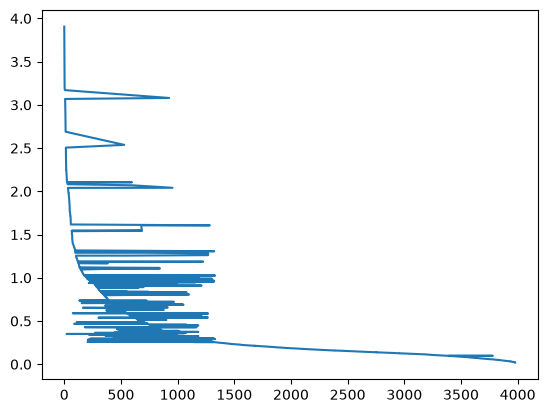

In [15]:
# Annotation: Calculate tenth-nearest-neighbour distances and draw an initial descending distance curve.
ns = 10
nbrs = NearestNeighbors(n_neighbors=ns).fit(stdDf)
distances, indices = nbrs.kneighbors(stdDf)
distanceDec = sorted(distances[:,ns-1], reverse=True)
plt.plot(indices[:,0], distanceDec)

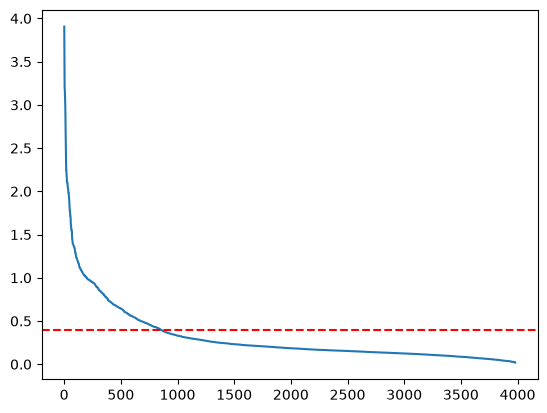

In [16]:
# Annotation: Plot the ordered neighbour distances and mark 0.4 as a candidate threshold.
plt.plot(list(range(1,len(indices)+1)), distanceDec)
plt.axhline(y=0.4,color='red',linestyle='--')

## 4. DBSCAN parameter comparison

DBSCAN is fitted for `eps` values 0.40, 0.45, and 0.50 with `min_samples=5`. The labels are stored as three alternative partitions, and the rest of the notebook uses the third partition.


In [17]:
# Annotation: Define the candidate DBSCAN neighbourhood radii.
epsilo=[0.4,0.45,.5]

In [18]:
# Annotation: Fit DBSCAN for every candidate radius with five minimum samples.
# Crea un diccionario para almacenar los resultados de DBSCAN
resultados_dbscan = {}

# Itera sobre los valores de epsilon
for epsilon in epsilo:
    # Crea una instancia de DBSCAN con el valor actual de epsilon
    dbscan = DBSCAN(eps=epsilon, min_samples=5)
    
    # Ajusta el modelo a tus datos
    dbscan.fit(stdDf)
    
    # Almacena los resultados en el diccionario
    resultados_dbscan[epsilon] = {
        'labels': dbscan.labels_,
        'core_sample_indices': dbscan.core_sample_indices_
    }


In [19]:
# Annotation: Attach the three candidate DBSCAN label arrays to the incident table.
carpetas['cluster1'] = resultados_dbscan[epsilo[0]]['labels']
carpetas['cluster2'] = resultados_dbscan[epsilo[1]]['labels']
carpetas['cluster3'] = resultados_dbscan[epsilo[2]]['labels']


In [20]:
# Annotation: Compare cluster-size and noise distributions across the three parameter settings.
# Utiliza value_counts() para contar el número de ocurrencias de cada valor único
conteo_valores1 = carpetas['cluster1'].value_counts()
conteo_valores2 = carpetas['cluster2'].value_counts()
conteo_valores3 = carpetas['cluster3'].value_counts()

# Muestra los resultados
print(conteo_valores1,conteo_valores2,conteo_valores3)

cluster1
 0     1095
 13     883
 22     671
 30     395
-1      361
 31      60
 17      59
 1       58
 24      58
 14      37
 16      28
 36      22
 23      20
 6       15
 18      14
 32      14
 15      13
 5       11
 10      10
 2        9
 3        9
 7        9
 35       9
 8        8
 25       8
 27       8
 40       8
 9        7
 20       7
 26       7
 37       7
 4        6
 21       6
 29       6
 38       6
 12       5
 11       5
 19       5
 28       5
 33       5
 34       5
 39       5
Name: count, dtype: int64 cluster2
 0     1106
 11     905
 19     672
 27     478
-1      305
 1       80
 15      60
 21      59
 12      43
 14      29
 28      27
 20      22
 13      13
 9       12
 5       12
 22      11
 23      11
 3       10
 7       10
 2        9
 6        9
 8        9
 31       9
 24       8
 34       8
 17       7
 32       7
 4        6
 26       6
 30       6
 10       5
 18       5
 16       5
 25       5
 29       5
 33       5
Name: count, dtype: 

## 5. Cluster validation

Silhouette is reported with and without DBSCAN noise. The scores are calculated from the unstandardized feature table even though DBSCAN was fitted to the standardized matrix. The validation should use `stdDf` to measure separation in the same feature space as the model.


In [21]:
# Annotation: Select the third DBSCAN partition and reconstruct its feature table for evaluation.
# Supongamos que 'community_id' identifica la comunidad en la tabla
community_data = carpetas[['latitudrad','longitudrad','año','grupo_etario2','genero2']]
community_labels =carpetas['cluster3']

In [22]:
# Annotation: Calculate silhouette after excluding records labelled as noise.
from sklearn.metrics import silhouette_score

# Filtrar datos excluyendo el ruido
valid_indices = community_labels != -1
filtered_data = community_data[valid_indices]
filtered_labels = community_labels[valid_indices]

# Calcular Silhouette Score si hay más de un clúster válido
if len(set(filtered_labels)) > 1:
    silhouette = silhouette_score(filtered_data, filtered_labels)
    print(f"Silhouette Score (excluyendo ruido): {silhouette}")
else:
    print("No se puede calcular el Silhouette Score: menos de 2 clústeres válidos.")


Silhouette Score (excluyendo ruido): 0.9437593048946743


In [23]:
# Annotation: Calculate silhouette while treating the noise label as an additional group.
# Calcular Silhouette Score incluyendo el ruido
if len(set(community_labels)) > 1:
    silhouette_with_noise = silhouette_score(community_data, community_labels)
    print(f"Silhouette Score (incluyendo ruido): {silhouette_with_noise}")
else:
    print("No se puede calcular el Silhouette Score: menos de 2 clústeres.")

Silhouette Score (incluyendo ruido): 0.8298648349631604


## 6. Select and characterize one DBSCAN cluster

The code constructs firearm- and bladed-weapon subsets but subsequently selects label `10` from the complete `carpetas` table. The stored cluster has 31 records, all labelled female and aged 19–64 in 2020.

DBSCAN label numbers are arbitrary. A fixed label such as `10` is not a reproducible selection criterion when preprocessing, record order, or parameters change.


In [24]:
# Annotation: Create firearm and bladed-weapon subsets and concatenate them into a combined table.
carpfuego1=carpetas[carpetas['Delito']=='HOMICIDIO_POR_ARMA_DE_FUEGO']
carpfuego2=carpetas[carpetas['Delito']=='HOMICIDIO_POR_ARMA_BLANCA']
carpfuego=pd.concat([carpfuego1,carpfuego2])

In [25]:
# Annotation: Inspect the years represented by DBSCAN label 10 in the combined weapon-specific subset.
carpfuego[carpfuego['cluster3']==10].Año_hecho

1376    2020.0
1377    2020.0
1392    2020.0
1429    2020.0
1522    2020.0
1545    2020.0
1556    2020.0
1649    2020.0
1693    2020.0
1739    2020.0
1770    2020.0
1818    2020.0
1892    2020.0
1905    2020.0
1906    2020.0
1973    2020.0
1995    2020.0
2029    2020.0
2077    2020.0
2146    2020.0
2149    2020.0
2192    2020.0
2248    2020.0
2297    2020.0
2305    2020.0
2311    2020.0
2314    2020.0
2374    2020.0
2437    2020.0
2439    2020.0
2608    2020.0
Name: Año_hecho, dtype: float64

In [26]:
# Annotation: Select DBSCAN label 10 from the complete incident table for downstream analysis.
cluster1=carpetas[carpetas['cluster3']==10]

## 7. Geographic representation of the selected cluster

The selected records are converted into point geometries and overlaid on AGEB poverty polygons. The point GeoDataFrame has no explicit CRS, although the coordinates are longitude and latitude; `EPSG:4326` should be assigned before spatial operations.


In [27]:
# Annotation: Extract longitude and latitude arrays from the selected DBSCAN cluster.
longitudes=cluster1.longitud.values
latitudes=cluster1.latitud.values

In [28]:
# Annotation: Convert the selected coordinates into Shapely points.
Puntos=[Point(lon,lat) for lon, lat in zip(longitudes, latitudes)]

In [29]:
# Annotation: Construct a point GeoDataFrame for the selected DBSCAN cluster.
gdf1=gpd.GeoDataFrame(geometry=Puntos)

In [30]:
# Annotation: Load AGEB poverty polygons and transform them to EPSG:4326.
alcal=gpd.read_file('ageb_pobreza.shp')
alcal=alcal.to_crs('EPSG:4326')

<Axes: >

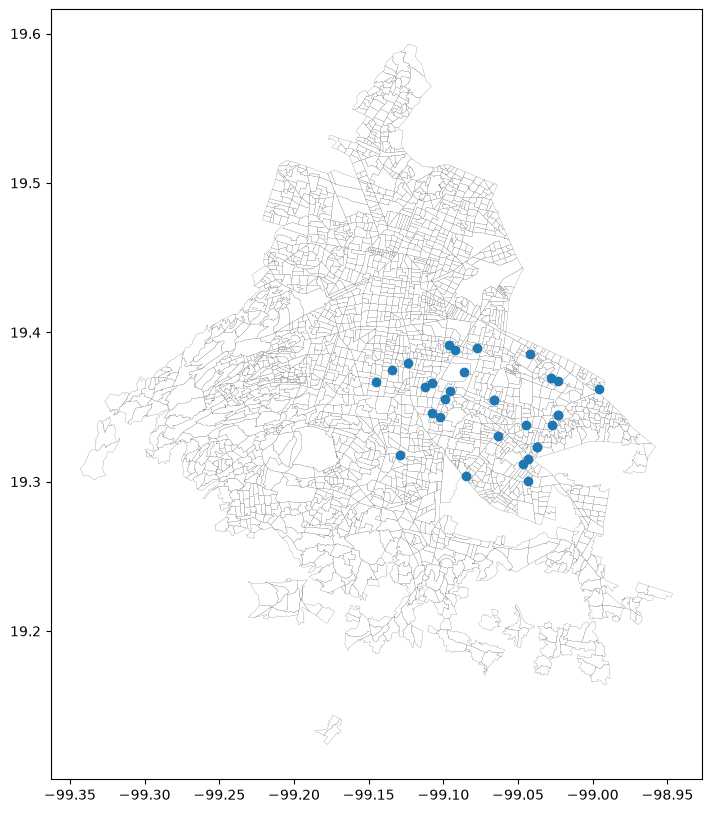

In [31]:
# Annotation: Plot the selected cluster over the AGEB polygon layer.
fig,ax=plt.subplots(figsize=(12,10))
alcal.plot(ax=ax,color='white',edgecolor='black',linewidth=0.1)
gdf1.plot(ax=ax)

In [32]:
# Annotation: Inspect sex labels in the selected DBSCAN cluster.
cluster1.Sexo

1376    Femenino
1377    Femenino
1392    Femenino
1429    Femenino
1522    Femenino
1545    Femenino
1556    Femenino
1649    Femenino
1693    Femenino
1739    Femenino
1770    Femenino
1818    Femenino
1892    Femenino
1905    Femenino
1906    Femenino
1973    Femenino
1995    Femenino
2029    Femenino
2077    Femenino
2146    Femenino
2149    Femenino
2192    Femenino
2248    Femenino
2297    Femenino
2305    Femenino
2311    Femenino
2314    Femenino
2374    Femenino
2437    Femenino
2439    Femenino
2608    Femenino
Name: Sexo, dtype: str

## 8. Demographic profile and AGEB enrichment

The notebook calculates sex and age-group percentages, assigns each point the poverty category and `CVEGEO` of its containing AGEB, and then restricts the analysis to Iztapalapa.


In [34]:
# Annotation: Calculate percentage distributions for sex and age group.
print(cluster1['Sexo'].value_counts(normalize=True).mul(100).round(2))
print(cluster1['grupo_etario'].value_counts(normalize=True).mul(100).round(2))

Sexo
Femenino    100.0
Name: proportion, dtype: float64
grupo_etario
19-64    100.0
0-18       0.0
65+        0.0
Name: proportion, dtype: float64


In [35]:
# Annotation: Report the dimensions of the selected DBSCAN cluster.
cluster1.shape


(31, 36)

In [94]:
# Annotation: Count distinct labels in the selected DBSCAN partition, including noise.
carpetas.cluster3.nunique()

32

In [95]:
# Annotation: Extract the cluster's unique year and convert it to text.
año=cluster1.año.unique()
año=str(año[0])

In [96]:
# Annotation: Inspect the selected-cluster point GeoDataFrame.
gdf1

,geometry
0,POINT (-99.03743 19.32319)
1,POINT (-99.03743 19.32319)
2,POINT (-99.04663 19.31168)
3,POINT (-99.04470 19.33767)
4,POINT (-99.02814 19.36908)
5,POINT (-99.14480 19.36657)
6,POINT (-98.99605 19.36170)
7,POINT (-99.10193 19.34331)
8,POINT (-99.04321 19.30062)
9,POINT (-99.10751 19.36607)


In [97]:
# Annotation: Copy the point GeoDataFrame for spatial enrichment.
gdf2=gdf1.copy()

In [98]:
# Annotation: List poverty-category values present in the AGEB polygon layer.
alcal.POBREZA.unique()

array(['(18, 34]', '[ 0, 18]', '(34, 50]', '(50, 70]',
       'Una vivienda particular habitada',
       'Sin viviendas particulares habitadas', '(70, 100]', nan],
      dtype=object)

In [99]:
# Annotation: Assign each point the poverty category and CVEGEO of its containing AGEB polygon.
gdf2['pobreza']=''
gdf2['CVE']=''
for i in range(0,len(alcal)):
    geom=alcal.geometry.iloc[i]
    pobre=alcal.POBREZA.iloc[i]
    cve=alcal.CVEGEO.iloc[i]
    for j in range(0,len(gdf2)):
        punto=gdf2.geometry.iloc[j]
        if geom.contains(punto):
            gdf2.loc[gdf2['geometry']==punto,'pobreza']= pobre
            gdf2.loc[gdf2['geometry']==punto,'CVE']= cve

In [100]:
# Annotation: Inspect the point layer after AGEB enrichment.
gdf2

,geometry,pobreza,CVE
0,POINT (-99.03743 19.32319),"(34, 50]",0900700013401
1,POINT (-99.03743 19.32319),"(34, 50]",0900700013401
2,POINT (-99.04663 19.31168),"[ 0, 18]",0901100011357
3,POINT (-99.04470 19.33767),"(34, 50]",0900700013863
4,POINT (-99.02814 19.36908),"(50, 70]",0900700010604
5,POINT (-99.14480 19.36657),"[ 0, 18]",0901400010863
6,POINT (-98.99605 19.36170),"(18, 34]",0900700011157
7,POINT (-99.10193 19.34331),"(34, 50]",0900700011388
8,POINT (-99.04321 19.30062),"[ 0, 18]",0901100011145
9,POINT (-99.10751 19.36607),"[ 0, 18]",0900700010727


<Axes: >

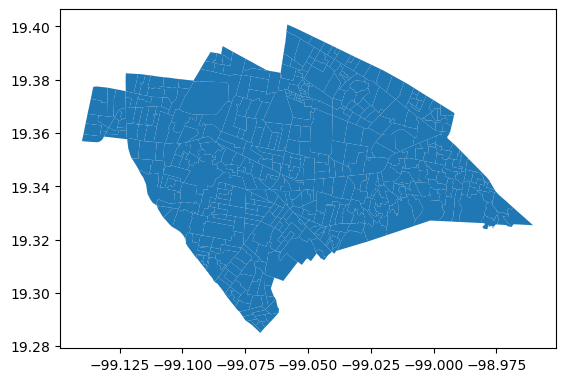

In [101]:
# Annotation: Select and plot Iztapalapa polygons using municipality code 09007.
alcalizt=alcal[alcal['CVEGEO'].str.contains('09007')]
alcalizt.plot()

In [103]:
# Annotation: Retain only points geometrically contained within the union of Iztapalapa polygons.
# Usamos 'within' para checar si cada punto está dentro de algún polígono de alcizt
# Pero como alcizt puede tener varios polígonos, primero hacemos un unary_union para juntarlos en uno solo:
union_poligonos = alcalizt.unary_union

# Filtrar puntos contenidos
gdf2 = gdf2[gdf2.geometry.within(union_poligonos)]

## 9. Point-level spatial grouping

The 23 Iztapalapa points with valid AGEB assignments are used to construct a geodesic-distance matrix. The seed function selects a point from the most frequent AGEB and minimizes average distance within that AGEB.

If no valid seed is found, the function returns a full pandas `Series` instead of the usual `[index, CVEGEO]` pair. This inconsistent return type causes several later cells to reinterpret geometry and poverty values as though they were identifiers.


> **Annotation:** Mark the start of the revised spatial-grouping procedure.

# Nueva forma de agregar

In [104]:
# Annotation: Count poverty categories among the retained Iztapalapa points.
gdf2['pobreza'].value_counts()

pobreza
(18, 34]     10
(34, 50]      9
[ 0, 18]      2
(50, 70]      1
(70, 100]     1
Name: count, dtype: int64

In [105]:
# Annotation: Create an explicit point identifier and discard points without an AGEB assignment.

gdf2['IDS']=gdf2.index.values
gdf2 = gdf2[~(gdf2['CVE'] == '')]

C:\Users\Luis Vilches\AppData\Roaming\Python\Python311\site-packages\geopandas\geodataframe.py:1543: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [106]:
# Annotation: Inspect the final point set used for distance-based grouping.
gdf2

,geometry,pobreza,CVE,IDS
0,POINT (-99.03743 19.32319),"(34, 50]",0900700013401,0
1,POINT (-99.03743 19.32319),"(34, 50]",0900700013401,1
3,POINT (-99.04470 19.33767),"(34, 50]",0900700013863,3
4,POINT (-99.02814 19.36908),"(50, 70]",0900700010604,4
6,POINT (-98.99605 19.36170),"(18, 34]",0900700011157,6
7,POINT (-99.10193 19.34331),"(34, 50]",0900700011388,7
9,POINT (-99.10751 19.36607),"[ 0, 18]",0900700010727,9
10,POINT (-99.06314 19.33075),"(18, 34]",0900700015906,10
11,POINT (-99.02333 19.34470),"(34, 50]",0900700012776,11
12,POINT (-99.13471 19.37457),"(18, 34]",0900700010483,12


In [310]:
# Annotation: Compute the complete pairwise geodesic-distance matrix in kilometres.
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
from geopy.distance import geodesic


def geod_distance(p1, p2):
    return geodesic((p1.y, p1.x), (p2.y, p2.x)).kilometers

# Calcular la matriz de distancias geodésicas
dist_matrix_geod = [
    [geod_distance(p1, p2) for p2 in gdf2['geometry']]
    for p1 in gdf2['geometry']
]

# Convertir la matriz a un DataFrame
dist_matrix_df = pd.DataFrame(dist_matrix_geod, index=gdf2.index, columns=gdf2.index)

dist_matrix_df


,0,1,3,4,6,7,9,10,11,12,...,16,18,19,22,23,24,25,26,28,30
0,0.000000,0.000000,1.776033,5.172969,6.089215,7.134803,8.760831,2.828694,2.804479,11.697335,...,6.883212,1.971550,7.521381,9.026799,7.346361,2.837861,5.140408,7.821711,1.080547,7.356169
1,0.000000,0.000000,1.776033,5.172969,6.089215,7.134803,8.760831,2.828694,2.804479,11.697335,...,6.883212,1.971550,7.521381,9.026799,7.346361,2.837861,5.140408,7.821711,1.080547,7.356169
3,1.776033,1.776033,0.000000,3.887769,5.762087,6.046129,7.309551,2.083457,2.376153,10.301325,...,5.272726,1.846829,5.847518,7.644137,5.884234,2.413034,3.999443,6.703135,2.514222,5.997657
4,5.172969,5.172969,3.887769,0.000000,3.468617,8.260929,8.344410,5.614295,2.745579,11.211890,...,2.295419,3.433851,6.084159,8.869555,7.125222,2.733003,0.503665,8.761176,6.186575,7.553502
6,6.089215,6.089215,5.762087,3.468617,0.000000,11.309216,11.719120,7.837304,3.428890,14.636224,...,5.470639,4.183585,9.523644,12.217400,10.432161,3.391325,2.966220,11.879154,7.148237,10.795801
7,7.134803,7.134803,6.046129,8.260929,11.309216,0.000000,2.586629,4.306788,8.260188,4.881826,...,7.833978,7.881404,3.712228,2.449793,2.011515,8.292958,8.665649,0.691470,6.935612,1.394294
9,8.760831,8.760831,7.309551,8.344410,11.719120,2.586629,0.000000,6.083956,9.154646,3.008767,...,7.215705,8.995765,2.403424,0.603364,1.425493,9.181047,8.820389,2.226782,8.821535,1.497938
10,2.828694,2.828694,2.083457,5.614295,7.837304,4.306788,6.083956,0.000000,4.458605,8.948237,...,6.431330,3.869780,5.271082,6.289018,4.711174,4.495620,5.833860,4.994709,2.737641,4.624856
11,2.804479,2.804479,2.376153,2.745579,3.428890,8.260188,9.154646,4.458605,0.000000,12.159737,...,4.889800,0.834954,7.290381,9.570635,7.761875,0.037611,2.548433,8.886066,3.884842,7.998275
12,11.697335,11.697335,10.301325,11.211890,14.636224,4.881826,3.008767,8.948237,12.159737,0.000000,...,9.825718,12.003277,5.130527,2.670829,4.424729,12.185749,11.700728,4.238973,11.671579,4.341167


In [311]:
# Annotation: Define a seed-selection function based on the most frequent AGEB and minimum mean distance.
import numpy as np

def find_central_point_by_community(gdf, dist_matrix_df):
    """
    Encuentra el punto central en la comunidad con el número máximo de elementos
    considerando una matriz de distancias.
    
    Args:
    - gdf (GeoDataFrame): GeoDataFrame con una columna 'comunidad' que agrupa los puntos.
    - dist_matrix_df (DataFrame): Matriz de distancias entre los índices de gdf.

    Returns:
    - central_point (list): [índice del punto central, comunidad asociada].
    """
    # Agrupar por 'comunidad' y contar el número de elementos por comunidad
    groups = gdf.groupby('CVE').count()

    # Encontrar el valor máximo y su índice correspondiente
    max_count = groups.max().max()  # Obtiene el valor máximo global
    max_group = groups[groups == max_count].dropna()  # Filtra las filas correspondientes al valor máximo
    indices = max_group.index.values  # Obtener los índices de comunidades con el valor máximo
    print("Índices con el valor máximo:", indices)

    # Inicializar variables para encontrar el punto central
    min_avg_distance = np.inf
    central_point = None

    # Iterar sobre los índices de las comunidades con el máximo valor
    for i in indices:
        # Filtrar los datos correspondientes a la comunidad actual
        dat = gdf[gdf['CVE'] == i]
        identifi = dat.index.values.tolist()  # Obtener los identificadores de los puntos

        # Calcular la distancia promedio para cada punto en esta comunidad
        for k in range(len(identifi)):
            ind1 = identifi[k]
            avg_distance = np.mean(
                [dist_matrix_df.loc[ind1, identifi[j]] for j in range(len(identifi)) if k != j]
            )
            # Actualizar el punto central si la distancia promedio es menor
            if avg_distance < min_avg_distance:
                min_avg_distance = avg_distance
                central_point = [ind1, i]
    if central_point == None: 
        
        central_point = gdf.sample(1).iloc[0]
        return central_point

    else:
        return central_point


In [312]:
# Annotation: Run the seed-selection function and inspect the selected point.
central_point = find_central_point_by_community(gdf2, dist_matrix_df)
print("Punto central:", central_point)

# Acceder a las coordenadas o datos del punto central
if central_point:
    print("Datos del punto central:")
    print(gdf2.loc[central_point[0]])


Índices con el valor máximo: ['0900700012776' '0900700013401' '0900700015111']
Punto central: [0, '0900700013401']
Datos del punto central:
geometry    POINT (-99.0374279669032 19.323186366422)
pobreza                                      (34, 50]
CVE                                     0900700013401
IDS                                                 0
Name: 0, dtype: object


In [313]:
# Annotation: Use the global mean pairwise distance as the point-group expansion threshold.
mean_distance = dist_matrix_df.values.mean()
print("Media general:", mean_distance)

Media general: 5.477615343654632


In [314]:
# Annotation: Retain a disabled population-range calculation from an earlier version.
#mean_pob = poblacion.pob.mean()
#std_pob =poblacion.pob.std()

###lim_inf_pob = mean_pob - std_pob
###lim_sup_pob = mean_pob + std_pob

In [315]:
# Annotation: Retain a disabled attempt to attach population counts to points.
"""dftest1['poblacion']=''
for i in range(0,len(dftest1)):
    row=dftest1.iloc[i]
    ag=row['ageb']
    pop=poblacion[poblacion['ageb']==ag]
    if len(pop) > 0:
        dftest1['poblacion'].iloc[i]=pop['pob'].values[0]
    else:
        dftest1['poblacion'].iloc[i]=0"""

"dftest1['poblacion']=''\nfor i in range(0,len(dftest1)):\n    row=dftest1.iloc[i]\n    ag=row['ageb']\n    pop=poblacion[poblacion['ageb']==ag]\n    if len(pop) > 0:\n        dftest1['poblacion'].iloc[i]=pop['pob'].values[0]\n    else:\n        dftest1['poblacion'].iloc[i]=0"

In [316]:
# Annotation: Display the selected seed identifier and AGEB code.
central_point

[0, '0900700013401']

## 10. Exploratory group 1

The first root is mapped and expanded with candidates that share its poverty category and lie within the global mean pairwise distance of at least one group member. This chain-expansion heuristic resembles single linkage and is separate from DBSCAN.


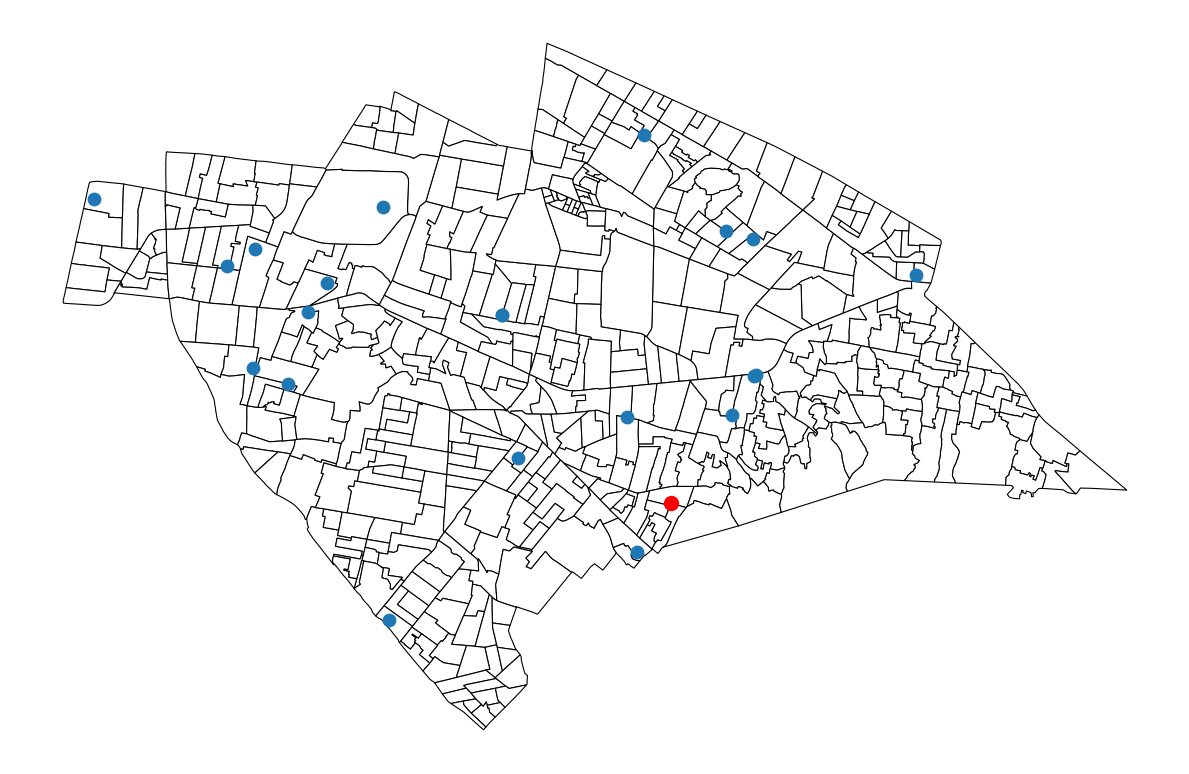

In [317]:
# Annotation: Map the first seed over the Iztapalapa candidate points and save the figure.
fig,ax=plt.subplots(figsize=(12,10))
alcalizt.plot(ax=ax,color='white',edgecolor='black',linewidth=0.8)
root=gdf2[gdf2['IDS']==central_point[0]]
#root=root[root['comunidad']==central_points[0]]
gdf2.plot(ax=ax,markersize=80,legend=True,categorical=True)
root.plot(ax=ax,markersize=100,color='red')

plt.axis('off')
plt.tight_layout()
plt.savefig("mapa_por_cluster1_4.jpg", format='jpg', dpi=300, bbox_inches='tight')

In [318]:
# Annotation: Initialize exploratory group 1 from the seed point.
grupo=gpd.GeoDataFrame(root,geometry=root.geometry)
grupo.columns

Index(['geometry', 'pobreza', 'CVE', 'IDS'], dtype='object')

In [319]:
# Annotation: Inspect the initial group-1 record.

grupo

,geometry,pobreza,CVE,IDS
0,POINT (-99.03743 19.32319),"(34, 50]",0900700013401,0


In [320]:
# Annotation: Create the candidate set after an attempted removal of the first seed.
gdf3=gdf2[gdf2['IDS'] != central_point[1]]
gdf3
#dftest2

,geometry,pobreza,CVE,IDS
0,POINT (-99.03743 19.32319),"(34, 50]",0900700013401,0
1,POINT (-99.03743 19.32319),"(34, 50]",0900700013401,1
3,POINT (-99.04470 19.33767),"(34, 50]",0900700013863,3
4,POINT (-99.02814 19.36908),"(50, 70]",0900700010604,4
6,POINT (-98.99605 19.36170),"(18, 34]",0900700011157,6
7,POINT (-99.10193 19.34331),"(34, 50]",0900700011388,7
9,POINT (-99.10751 19.36607),"[ 0, 18]",0900700010727,9
10,POINT (-99.06314 19.33075),"(18, 34]",0900700015906,10
11,POINT (-99.02333 19.34470),"(34, 50]",0900700012776,11
12,POINT (-99.13471 19.37457),"(18, 34]",0900700010483,12


In [321]:
# Annotation: Store the modal poverty category of group 1.
listapobreza=[]
listapobreza.extend(grupo['pobreza'].mode())

In [322]:
# Annotation: Display the stored poverty-category list.
listapobreza

['(34, 50]']

In [323]:
# Annotation: Expand group 1 using equal poverty and the global mean-distance threshold.
import pandas as pd

# Supongamos que tienes los DataFrames dftest2 y grupo, y la matriz de distancias dist_matrix_df ya definidos
# También asumiendo que lim_inf_pob, lim_sup_pob, y mean_distance ya están definidos

# Inicializa la columna 'pop_range' en dftest2
#dftest2['pop_range'] = ''

# Itera sobre las filas de dftest2
dftest2=gdf3.copy()
for i in range(len(dftest2)):
    row2 = dftest2.iloc[i]
    ind2 = row2['IDS']
    #pob2 = row2['poblacion']
    rangpob2 = row2['pobreza']
    
    for j in range(len(grupo)):
        row1 = grupo.iloc[j]
        ind1 = row1['IDS']
        #pob1 = row1['poblacion']
        rangpob = row1['pobreza']
        
        distance_value = dist_matrix_df.loc[ind1, ind2]
        if (distance_value <= mean_distance) and (rangpob == rangpob2):

            grupo = pd.concat([grupo, pd.DataFrame([row2])], ignore_index=True)
            break  # Salir del bucle interno después de agregar la fila

print(grupo)



                     geometry   pobreza            CVE  IDS
0  POINT (-99.03743 19.32319)  (34, 50]  0900700013401    0
1  POINT (-99.03743 19.32319)  (34, 50]  0900700013401    0
2  POINT (-99.03743 19.32319)  (34, 50]  0900700013401    1
3  POINT (-99.04470 19.33767)  (34, 50]  0900700013863    3
4  POINT (-99.02333 19.34470)  (34, 50]  0900700012776   11
5  POINT (-99.08497 19.30349)  (34, 50]  0900700013492   15
6  POINT (-99.02302 19.34487)  (34, 50]  0900700012776   24
7  POINT (-99.10789 19.34596)  (34, 50]  0900700011369   26
8  POINT (-99.04305 19.31501)  (34, 50]  0900700015380   28


In [324]:
# Annotation: Inspect poverty categories represented in group 1.
grupo['pobreza'].unique().tolist()

['(34, 50]']

In [325]:
# Annotation: Store group-1 identifiers and report its size.
listaids=grupo['IDS'].values.tolist()
len(grupo)

9

In [326]:
# Annotation: Remove group-1 members from the remaining candidates.
dftest3 = dftest2[~dftest2['IDS'].isin(listaids)]
dftest3['pobreza'].unique()

array(['(50, 70]', '(18, 34]', '(34, 50]', '[ 0, 18]', '(70, 100]'],
      dtype=object)

In [327]:
# Annotation: Report the number of points remaining after group 1.
len(dftest3)

15

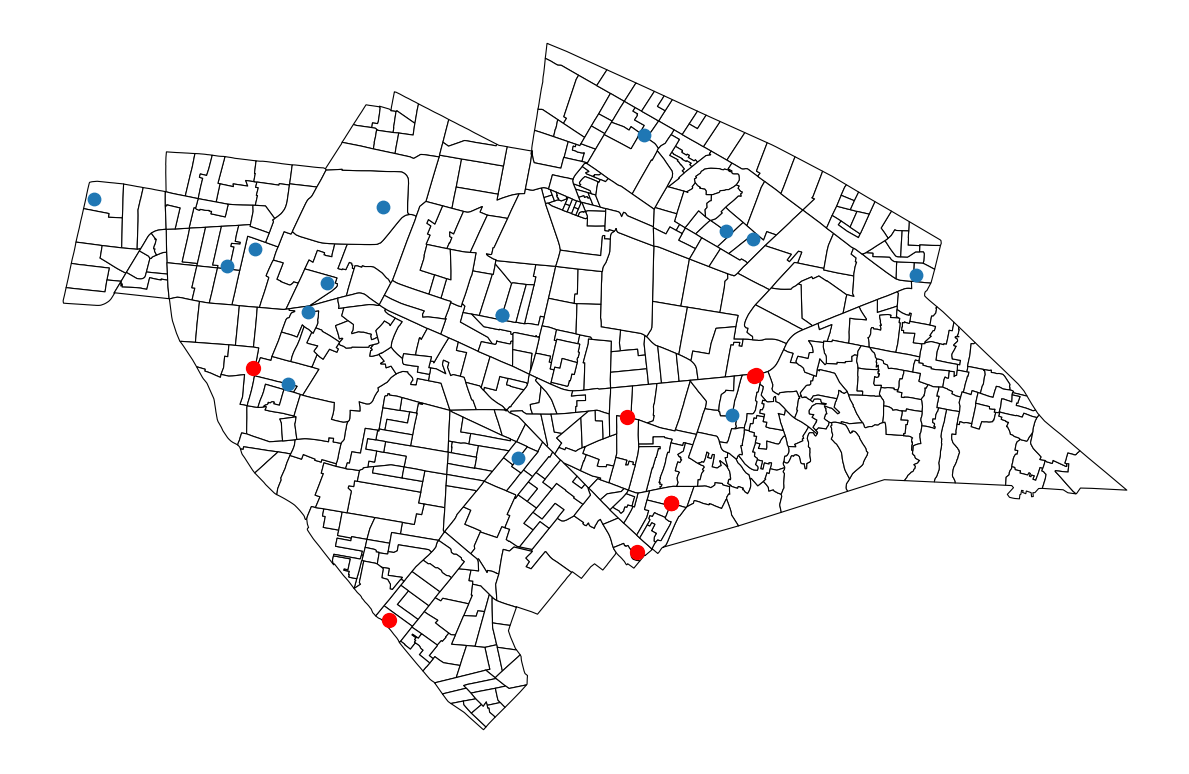

In [328]:
# Annotation: Map group 1 and the remaining points, then save the figure.
fig,ax=plt.subplots(figsize=(12,10))
alcalizt.plot(ax=ax,color='white',edgecolor='black',linewidth=0.8)
grupo.plot(ax=ax,markersize=100,color='red')

dftest3.plot(ax=ax,markersize=80,categorical=True)

plt.axis('off')
plt.tight_layout()
plt.savefig("mapa_por_cluster1_5.jpg", format='jpg', dpi=300, bbox_inches='tight')

In [329]:
# Annotation: Assign label 1 to the first exploratory group.
grupo['newgroup']=1

In [330]:
# Annotation: Inspect the complete AGEB polygon layer before label transfer.
alcal

,CVEGEO,POBREZA,POBREZAEX,ID,geometry,cluster
0,0900200010010,"(18, 34]","[ 0, 20]",1,"POLYGON ((-99.20307 19.51415, -99.20319 19.513...",
1,0900200010025,"[ 0, 18]","[ 0, 20]",2,"POLYGON ((-99.19662 19.51270, -99.19662 19.511...",
2,090020001003A,"[ 0, 18]","[ 0, 20]",3,"POLYGON ((-99.20658 19.51169, -99.20611 19.511...",
3,0900200010044,"[ 0, 18]","[ 0, 20]",4,"POLYGON ((-99.20530 19.51033, -99.20529 19.510...",
4,0900200010097,"[ 0, 18]","[ 0, 20]",5,"POLYGON ((-99.20573 19.50454, -99.20630 19.504...",
...,...,...,...,...,...,...
2427,0901700011488,"(34, 50]","[ 0, 20]",2428,"POLYGON ((-99.05931 19.42789, -99.05934 19.427...",
2428,0901700011492,"(34, 50]","[ 0, 20]",2429,"POLYGON ((-99.05931 19.42789, -99.05794 19.426...",
2429,0901700011505,"[ 0, 18]","[ 0, 20]",2430,"POLYGON ((-99.06102 19.42776, -99.05995 19.426...",
2430,090170001151A,"(18, 34]","[ 0, 20]",2431,"POLYGON ((-99.06253 19.42663, -99.06281 19.426...",


## 11. Transfer group 1 to AGEB polygons

Incident-level group labels are propagated to AGEB polygons through `CVEGEO`, producing the core polygon layer for the first group.


In [331]:
# Annotation: Create the AGEB polygon layer associated with group 1.
# Crear un DataFrame vacío para almacenar los resultados
alcgrupo1 = gpd.GeoDataFrame()

# Lista de IDs de ageb y valores de cluster de grupo
agsgru = grupo.CVE.values.tolist()
lista_cluster = grupo.newgroup.values.tolist()
alcal['cluster']=''
# Asignar el valor del cluster a alcshp
filas_a_agregar = []
for i in range(len(alcal)):
    row2 = alcal.iloc[i]
    if row2.CVEGEO in agsgru:
        # Obtener el valor del cluster correspondiente a la ageb de alcshp
        cluster_value = lista_cluster[agsgru.index(row2.CVEGEO)]
        # Asignar el valor del cluster a la columna 'cluster' en alcshp
        row2['cluster'] = cluster_value
        # Agregar la fila a la lista de filas a agregar
        filas_a_agregar.append(row2)

# Concatenar las filas a agregar al DataFrame alcgrupo1
alcgrupo1 = pd.concat([alcgrupo1, pd.DataFrame(filas_a_agregar)], ignore_index=True)

# Mostrar el resultado
alcgrupo1=gpd.GeoDataFrame(alcgrupo1,geometry=alcgrupo1.geometry)

C:\Users\Luis Vilches\AppData\Local\Temp\ipykernel_1828\1894859619.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  row2['cluster'] = cluster_value


In [332]:
# Annotation: Count polygons assigned to group 1.
alcgrupo1.cluster.value_counts()

cluster
1    6
Name: count, dtype: int64

In [333]:
# Annotation: Inspect the group-1 polygon GeoDataFrame.
alcgrupo1

,CVEGEO,POBREZA,POBREZAEX,ID,geometry,cluster
0,0900700011369,"(34, 50]","[ 0, 20]",817,"POLYGON ((-99.11326 19.34489, -99.11296 19.345...",1
1,0900700012776,"(34, 50]","[ 0, 20]",906,"POLYGON ((-99.02534 19.34477, -99.02475 19.344...",1
2,0900700013401,"(34, 50]","[ 0, 20]",949,"POLYGON ((-99.03957 19.32325, -99.04028 19.323...",1
3,0900700013492,"(34, 50]","[ 0, 20]",952,"POLYGON ((-99.08287 19.30377, -99.08256 19.303...",1
4,0900700013863,"(34, 50]","[ 0, 20]",984,"POLYGON ((-99.04384 19.34295, -99.04390 19.341...",1
5,0900700015380,"(34, 50]","[ 0, 20]",1109,"POLYGON ((-99.04410 19.31453, -99.04403 19.314...",1


In [334]:
# Annotation: Propagate group-1 labels back to the complete AGEB layer.
# Crear una columna 'cluster' en alcshp
alcal['cluster'] = ''

# Iterar sobre cada fila de alcgrupo1
for i in range(len(alcgrupo1)):
    row = alcgrupo1.iloc[i]
    ageb = row['CVEGEO']
    cluster_value = row['cluster']
    
    # Buscar la fila correspondiente en alcshp y asignar el valor del cluster
    alcal.loc[alcal['CVEGEO'] == ageb, 'cluster'] = cluster_value


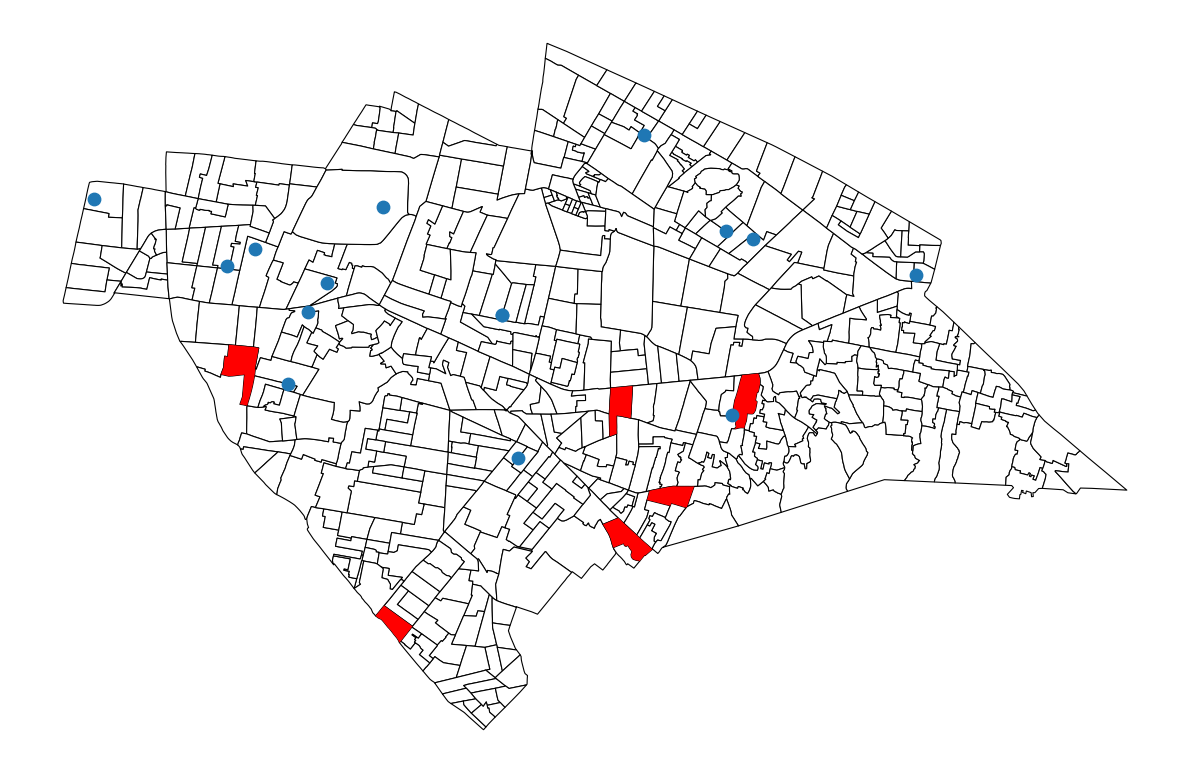

In [335]:
# Annotation: Map group-1 polygons with remaining candidate points and save the figure.
fig,ax=plt.subplots(figsize=(12,10))
alcalizt.plot(ax=ax,color='white',edgecolor='black',linewidth=0.8)
alcgrupo1.plot(ax=ax,color='red')

dftest3.plot(ax=ax,markersize=80,categorical=True)

plt.axis('off')
plt.tight_layout()
plt.savefig("mapa_por_cluster1_6.jpg", format='jpg', dpi=300, bbox_inches='tight')

## 12. Queen-contiguity extension

A second AGEB layer is merged with poverty ranges and converted into Queen contiguity weights. The extension function adds adjacent polygons whose poverty category matches the categories represented by the current group.

Despite its name, the stored function expands from the original polygons in a fixed loop; it does not recursively continue through every newly added neighbour until convergence.


In [139]:
# Annotation: Load a second Mexico City AGEB layer for contiguity analysis.
alcshp=gpd.read_file('09a.shp').to_crs('EPSG:4326')

ERROR:fiona._env:PROJ: proj_identify: C:\Program Files\PostgreSQL\13\share\contrib\postgis-3.1\proj\proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.
ERROR:fiona._env:PROJ: proj_identify: C:\Program Files\PostgreSQL\13\share\contrib\postgis-3.1\proj\proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.


In [140]:
# Annotation: Inspect the Iztapalapa point layer used for grouping.
gdf2

,geometry,pobreza,CVE,IDS
0,POINT (-99.03743 19.32319),"(34, 50]",0900700013401,0
1,POINT (-99.03743 19.32319),"(34, 50]",0900700013401,1
3,POINT (-99.04470 19.33767),"(34, 50]",0900700013863,3
4,POINT (-99.02814 19.36908),"(50, 70]",0900700010604,4
6,POINT (-98.99605 19.36170),"(18, 34]",0900700011157,6
7,POINT (-99.10193 19.34331),"(34, 50]",0900700011388,7
9,POINT (-99.10751 19.36607),"[ 0, 18]",0900700010727,9
10,POINT (-99.06314 19.33075),"(18, 34]",0900700015906,10
11,POINT (-99.02333 19.34470),"(34, 50]",0900700012776,11
12,POINT (-99.13471 19.37457),"(18, 34]",0900700010483,12


In [141]:
# Annotation: Load the AGEB socioeconomic-range table.
pobre=pd.read_csv('rezagorangos.csv',encoding='utf-8')

In [142]:
# Annotation: Inspect the socioeconomic table before merging.
pobre

,Unnamed: 0,Clave de entidad,Entidad \nfederativa,Clave de municipio,Municipio,Clave de \nAGEB,Rango de pobreza (%),Rango de pobreza extrema (%),CVE_AGEB,Clave localidad
0,0,9,Ciudad de México,2,Azcapotzalco,0900200010010,"(18, 34]","[ 0, 20]",0010,1
1,1,9,Ciudad de México,2,Azcapotzalco,0900200010025,"[ 0, 18]","[ 0, 20]",0025,1
2,2,9,Ciudad de México,2,Azcapotzalco,090020001003A,"[ 0, 18]","[ 0, 20]",003A,1
3,3,9,Ciudad de México,2,Azcapotzalco,0900200010044,"[ 0, 18]","[ 0, 20]",0044,1
4,4,9,Ciudad de México,2,Azcapotzalco,0900200010097,"[ 0, 18]","[ 0, 20]",0097,1
...,...,...,...,...,...,...,...,...,...,...
2427,2427,9,Ciudad de México,17,Venustiano Carranza,0901700011488,"(34, 50]","[ 0, 20]",1488,1
2428,2428,9,Ciudad de México,17,Venustiano Carranza,0901700011492,"(34, 50]","[ 0, 20]",1492,1
2429,2429,9,Ciudad de México,17,Venustiano Carranza,0901700011505,"[ 0, 18]","[ 0, 20]",1505,1
2430,2430,9,Ciudad de México,17,Venustiano Carranza,090170001151A,"(18, 34]","[ 0, 20]",151A,1


In [143]:
# Annotation: Rename the municipality key and manually format municipality codes with leading zeros.
pobre=pobre.rename(columns={'Clave de municipio':'CVE_MUN'})
pobre.CVE_MUN=pobre.CVE_MUN.replace(2,'002')
pobre.CVE_MUN=pobre.CVE_MUN.replace(3,'003')
pobre.CVE_MUN=pobre.CVE_MUN.replace(4,'004')
pobre.CVE_MUN=pobre.CVE_MUN.replace(5,'005')
pobre.CVE_MUN=pobre.CVE_MUN.replace(6,'006')
pobre.CVE_MUN=pobre.CVE_MUN.replace(7,'007')
pobre.CVE_MUN=pobre.CVE_MUN.replace(8,'008')
pobre.CVE_MUN=pobre.CVE_MUN.replace(9,'009')
pobre.CVE_MUN=pobre.CVE_MUN.replace(10,'010')
pobre.CVE_MUN=pobre.CVE_MUN.replace(11,'011')
pobre.CVE_MUN=pobre.CVE_MUN.replace(12,'012')
pobre.CVE_MUN=pobre.CVE_MUN.replace(13,'013')
pobre.CVE_MUN=pobre.CVE_MUN.replace(14,'014')
pobre.CVE_MUN=pobre.CVE_MUN.replace(15,'015')
pobre.CVE_MUN=pobre.CVE_MUN.replace(16,'016')
pobre.CVE_MUN=pobre.CVE_MUN.replace(17,'017')

In [144]:
# Annotation: Rename the AGEB key and merge socioeconomic attributes with AGEB polygons.
pobre=pobre.rename(columns={'Clave de \nAGEB':'CVEGEO'})
alcshppob=pd.merge(alcshp,pobre,on=['CVEGEO'])

In [145]:
# Annotation: Construct Queen contiguity weights for the merged AGEB layer.
from libpysal.weights import Queen

w_queen = Queen.from_dataframe(alcshppob)

C:\Users\Luis Vilches\AppData\Roaming\Python\Python311\site-packages\libpysal\cg\alpha_shapes.py:38: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @jit
C:\Users\Luis Vilches\AppData\Roaming\Python\Python311\site-packages\libpysal\cg\alpha_shapes.py:164: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @jit
C:\Users\Luis Vilches\AppData\Roaming\Python\Python311\site

In [146]:
# Annotation: Inspect the merged AGEB and socioeconomic GeoDataFrame.
alcshppob

,CVEGEO,CVE_ENT,CVE_MUN_x,CVE_LOC,CVE_AGEB_x,geometry,Unnamed: 0,Clave de entidad,Entidad \nfederativa,CVE_MUN_y,Municipio,Rango de pobreza (%),Rango de pobreza extrema (%),CVE_AGEB_y,Clave localidad
0,0901400010543,09,014,0001,0543,"POLYGON ((-99.18808 19.38117, -99.18817 19.380...",1949,9,Ciudad de México,014,Benito Juárez,"[ 0, 18]","[ 0, 20]",0543,1
1,0901400010967,09,014,0001,0967,"POLYGON ((-99.16339 19.35940, -99.16345 19.358...",1991,9,Ciudad de México,014,Benito Juárez,"[ 0, 18]","[ 0, 20]",0967,1
2,0901400010045,09,014,0001,0045,"POLYGON ((-99.16532 19.40076, -99.16546 19.400...",1899,9,Ciudad de México,014,Benito Juárez,"[ 0, 18]","[ 0, 20]",0045,1
3,0901400010168,09,014,0001,0168,"POLYGON ((-99.13476 19.39472, -99.13420 19.394...",1911,9,Ciudad de México,014,Benito Juárez,"[ 0, 18]","[ 0, 20]",0168,1
4,0901400010971,09,014,0001,0971,"POLYGON ((-99.16271 19.36467, -99.16181 19.364...",1992,9,Ciudad de México,014,Benito Juárez,"[ 0, 18]","[ 0, 20]",0971,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2426,0901100211003,09,011,0021,1003,"POLYGON ((-98.99886 19.24043, -98.99865 19.240...",1553,9,Ciudad de México,011,Tláhuac,Sin viviendas particulares habitadas,Sin viviendas particulares habitadas,1003,21
2427,0901100240734,09,011,0024,0734,"POLYGON ((-98.97298 19.22324, -98.97318 19.222...",1558,9,Ciudad de México,011,Tláhuac,"(34, 50]","[ 0, 20]",0734,24
2428,0901100011450,09,011,0001,1450,"POLYGON ((-99.03640 19.28327, -99.03551 19.283...",1541,9,Ciudad de México,011,Tláhuac,"(50, 70]","[ 0, 20]",1450,1
2429,0901100010753,09,011,0001,0753,"POLYGON ((-99.02128 19.30522, -99.02118 19.305...",1501,9,Ciudad de México,011,Tláhuac,"(34, 50]","[ 0, 20]",0753,1


In [147]:
# Annotation: Inspect the current incident-level spatial group.
grupo

,geometry,pobreza,CVE,IDS,newgroup
0,POINT (-99.03743 19.32319),"(34, 50]",0900700013401,0,1
1,POINT (-99.03743 19.32319),"(34, 50]",0900700013401,0,1
2,POINT (-99.03743 19.32319),"(34, 50]",0900700013401,1,1
3,POINT (-99.04470 19.33767),"(34, 50]",0900700013863,3,1
4,POINT (-99.02333 19.34470),"(34, 50]",0900700012776,11,1
5,POINT (-99.08497 19.30349),"(34, 50]",0900700013492,15,1
6,POINT (-99.02302 19.34487),"(34, 50]",0900700012776,24,1
7,POINT (-99.10789 19.34596),"(34, 50]",0900700011369,26,1
8,POINT (-99.04305 19.31501),"(34, 50]",0900700015380,28,1


In [148]:
# Annotation: Mark group-1 AGEBs in the merged polygon layer and inspect their poverty ranges.
listag=grupo['CVE'].values.tolist()

alcshppob['grupo']=''

for ageb in listag:
    # Asignar el valor 1 en 'grupo' para las filas que tienen 'CVE_AGEB_x' igual a ageb y 'alcaldia_hechos' igual a alcaldia
    alcshppob.loc[(alcshppob['CVEGEO'] == ageb), 'grupo'] = 1
    
    


alcshppob[alcshppob['grupo']==1]['Rango de pobreza (%)'].unique()

array(['(34, 50]'], dtype=object)

In [149]:
# Annotation: Extract numeric group identifiers present in the polygon layer.
gruposcat=alcshppob.grupo.unique()
gruposcat = [x for x in gruposcat if isinstance(x, (int, float))]
gruposcat

[1]

In [150]:
# Annotation: Define and apply a poverty-matched Queen-neighbour extension for polygon groups.
def obtener_poligonos_vecinos_extendidos(agspobtlaf, w_queen, gruposcat):
    fags = pd.DataFrame(columns=agspobtlaf.columns)

    for gru in gruposcat:
        dif = agspobtlaf[agspobtlaf.grupo == gru]
        polis = len(dif)
        
        for i in range(0, polis):
            id_poligono = dif.index[i]
            vecinos = w_queen.neighbors[id_poligono]

            prpobini = dif['Rango de pobreza (%)'].unique()

            # Obtener los polígonos vecinos
            poligonos_vecinos = agspobtlaf.iloc[vecinos]

            # Inicializar una lista para almacenar los índices de los polígonos vecinos
            indices_vecinos = []

            # Inicializar la población acumulada
            #pobla = 0
            #rango_inferior = media - std
            #rango_superior = media + std

            # Iterar sobre los vecinos del polígono inicial
            for indice_vecino in vecinos:
                # Obtener los datos del polígono vecino actual
                try:
                    datos_vecino = agspobtlaf.loc[indice_vecino]
        
                    # Verificar si el rango de pobreza del vecino es igual a alguno de los rangos de pobreza del polígono inicial
                    if (datos_vecino['Rango de pobreza (%)'] in prpobini):
                        # Agregar el índice del vecino a la lista de índices
                        indices_vecinos.append(indice_vecino)
                except KeyError as e:
                    print(f"KeyError: {e}")


            # Filtrar los polígonos vecinos según los índices acumulados
            poligonos_vecinos = agspobtlaf.loc[indices_vecinos]

            # Agregar el grupo a los polígonos vecinos
            poligonos_vecinos['grupo'] = gru
            

            # Concatenar los polígonos vecinos al DataFrame original
            dif = pd.concat([dif, poligonos_vecinos]).drop_duplicates()

        # Concatenar los resultados al DataFrame final
        fags = pd.concat([fags, dif])
    
    

    return fags

# Utilizar la función
agpobtlafveci = obtener_poligonos_vecinos_extendidos(alcshppob, w_queen, gruposcat)

C:\Users\Luis Vilches\AppData\Local\Temp\ipykernel_1828\828583937.py:50: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  fags = pd.concat([fags, dif])


In [151]:
# Annotation: Inspect the Queen-expanded polygon set for group 1.
agpobtlafveci

,CVEGEO,CVE_ENT,CVE_MUN_x,CVE_LOC,CVE_AGEB_x,geometry,Unnamed: 0,Clave de entidad,Entidad \nfederativa,CVE_MUN_y,Municipio,Rango de pobreza (%),Rango de pobreza extrema (%),CVE_AGEB_y,Clave localidad,grupo
914,0900700013492,09,007,0001,3492,"POLYGON ((-99.08097 19.30239, -99.08103 19.302...",951,9,Ciudad de México,007,Iztapalapa,"(34, 50]","[ 0, 20]",3492,1,1
998,0900700011369,09,007,0001,1369,"POLYGON ((-99.11084 19.34979, -99.11022 19.349...",816,9,Ciudad de México,007,Iztapalapa,"(34, 50]","[ 0, 20]",1369,1,1
1094,0900700012776,09,007,0001,2776,"POLYGON ((-99.02235 19.34321, -99.02260 19.342...",905,9,Ciudad de México,007,Iztapalapa,"(34, 50]","[ 0, 20]",2776,1,1
1163,0900700013401,09,007,0001,3401,"POLYGON ((-99.03462 19.32263, -99.03472 19.322...",948,9,Ciudad de México,007,Iztapalapa,"(34, 50]","[ 0, 20]",3401,1,1
1231,0900700013863,09,007,0001,3863,"POLYGON ((-99.04408 19.33838, -99.04412 19.337...",983,9,Ciudad de México,007,Iztapalapa,"(34, 50]","[ 0, 20]",3863,1,1
1268,0900700015380,09,007,0001,5380,"POLYGON ((-99.04536 19.31983, -99.04529 19.319...",1108,9,Ciudad de México,007,Iztapalapa,"(34, 50]","[ 0, 20]",5380,1,1
917,0900700014325,09,007,0001,4325,"POLYGON ((-99.08162 19.29880, -99.08136 19.298...",1019,9,Ciudad de México,007,Iztapalapa,"(34, 50]","[ 0, 20]",4325,1,1
1165,0900700013488,09,007,0001,3488,"POLYGON ((-99.08165 19.30838, -99.08216 19.307...",950,9,Ciudad de México,007,Iztapalapa,"(34, 50]","[ 0, 20]",3488,1,1
1166,0900700013505,09,007,0001,3505,"POLYGON ((-99.07590 19.30205, -99.07585 19.302...",952,9,Ciudad de México,007,Iztapalapa,"(34, 50]","[ 0, 20]",3505,1,1
1030,0900700011208,09,007,0001,1208,"POLYGON ((-99.10678 19.35619, -99.10576 19.356...",803,9,Ciudad de México,007,Iztapalapa,"(34, 50]","[ 0, 20]",1208,1,1


In [152]:
# Annotation: Convert the expanded group-1 result to a GeoDataFrame.
agpobtlafveci=gpd.GeoDataFrame(agpobtlafveci,geometry=agpobtlafveci.geometry)

In [153]:
# Annotation: Inspect poverty categories in the expanded group-1 polygons.
agpobtlafveci['Rango de pobreza (%)'].unique()

array(['(34, 50]'], dtype=object)

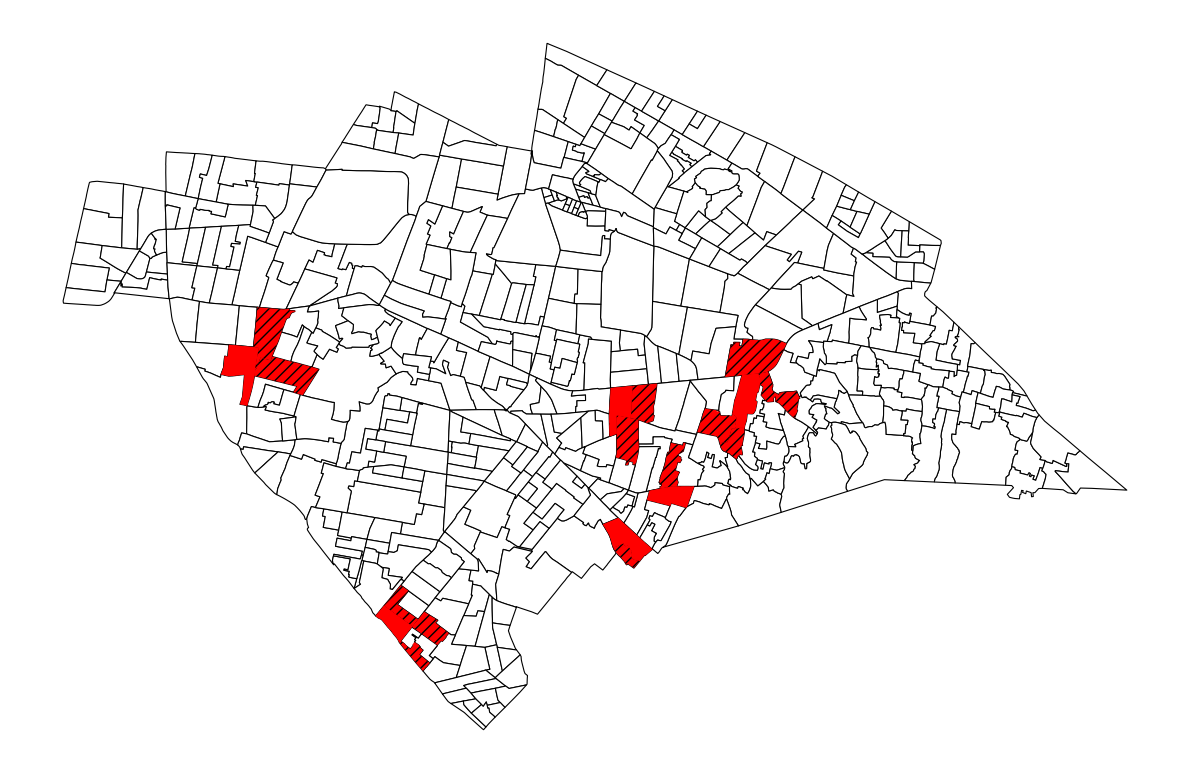

In [158]:
# Annotation: Map group-1 core polygons and poverty-matched Queen neighbours over Iztapalapa.
fig,ax=plt.subplots(figsize=(12,10))
alcalizt.plot(ax=ax,color='white',edgecolor='black',linewidth=0.8)
#agpobtlafveci.plot(ax=ax,column='Qpob',legend=True,cmap='viridis')
#agpobtlafveci.plot(ax=ax,column='cluster',legend=True,cmap='viridis')
agpobtlafveci.plot(ax=ax,color='red',hatch='///')
alcgrupo1.plot(ax=ax,color='red')
plt.axis('off')
plt.tight_layout()
plt.savefig("mapa_por_cluster1_7.jpg", format='jpg', dpi=300, bbox_inches='tight')

## 13. Exploratory group 2

The seed, distance-expansion, polygon-transfer, and Queen-neighbour procedures are repeated for the remaining points. The repeated blocks should be replaced with a single parameterized function in the final replication version.


In [159]:
# Annotation: Count poverty categories remaining before constructing group 2.
dftest3['pobreza'].value_counts()

pobreza
(18, 34]     10
[ 0, 18]      2
(50, 70]      1
(34, 50]      1
(70, 100]     1
Name: count, dtype: int64

In [160]:
# Annotation: Select a seed for exploratory group 2.
central_point = find_central_point_by_community(dftest3, dist_matrix_df)
print("Punto central:", central_point)



Índices con el valor máximo: ['0900700015111']
Punto central: [13, '0900700015111']


In [161]:
# Annotation: Normalize the group-2 seed to a two-element list.
central_point=[central_point[0],central_point[1]]
central_point

[13, '0900700015111']

In [162]:
# Annotation: Select the group-2 root by its IDS value.
root=dftest3[dftest3['IDS']==central_point[0]]
root

,geometry,pobreza,CVE,IDS
13,POINT (-99.06581 19.35500),"(18, 34]",0900700015111,13


<Axes: >

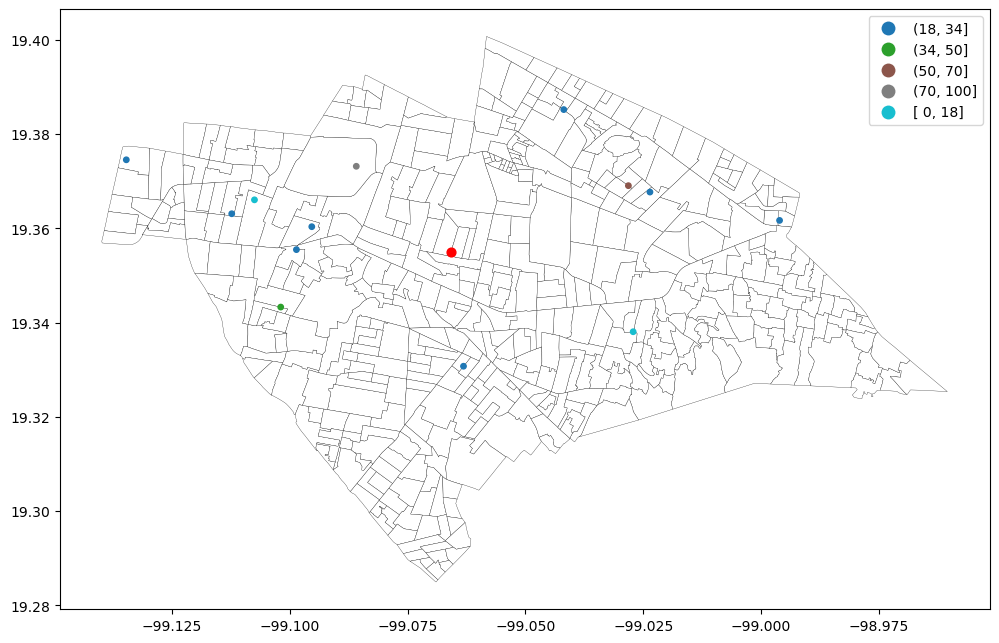

In [163]:
# Annotation: Map the group-2 root over remaining candidate points.
fig,ax=plt.subplots(figsize=(12,10))
alcalizt.plot(ax=ax,color='white',edgecolor='black',linewidth=0.2)
dftest3.plot(ax=ax,column='pobreza',markersize=15,legend=True,categorical=True)
root.plot(ax=ax,markersize=40,color='red')


In [164]:
# Annotation: Initialize the group-2 GeoDataFrame from its root.
grupo=gpd.GeoDataFrame(root,geometry=root.geometry)
grupo.columns

Index(['geometry', 'pobreza', 'CVE', 'IDS'], dtype='object')

In [165]:
# Annotation: Inspect the root poverty category for group 2.
grupo['pobreza']

13    (18, 34]
Name: pobreza, dtype: object

In [166]:
# Annotation: Display the previously stored poverty-category list.
listapobreza

['(34, 50]']

In [167]:
# Annotation: Remove the group-2 root from the candidate set.
dftest4=dftest3[dftest3['IDS'] != central_point[0]]
dftest4

,geometry,pobreza,CVE,IDS
4,POINT (-99.02814 19.36908),"(50, 70]",0900700010604,4
6,POINT (-98.99605 19.36170),"(18, 34]",0900700011157,6
7,POINT (-99.10193 19.34331),"(34, 50]",0900700011388,7
9,POINT (-99.10751 19.36607),"[ 0, 18]",0900700010727,9
10,POINT (-99.06314 19.33075),"(18, 34]",0900700015906,10
12,POINT (-99.13471 19.37457),"(18, 34]",0900700010483,12
14,POINT (-99.06581 19.35500),"(18, 34]",0900700015111,14
16,POINT (-99.04185 19.38523),"(18, 34]",0900700013562,16
18,POINT (-99.02713 19.33807),"[ 0, 18]",0900700015003,18
19,POINT (-99.08589 19.37319),"(70, 100]",0900700012475,19


In [168]:
# Annotation: Expand group 2 using equal poverty and the mean-distance threshold.
import pandas as pd

# Supongamos que tienes los DataFrames dftest2 y grupo, y la matriz de distancias dist_matrix_df ya definidos
# También asumiendo que lim_inf_pob, lim_sup_pob, y mean_distance ya están definidos


# Itera sobre las filas de dftest2
for i in range(len(dftest4)):
    row2 = dftest4.iloc[i]
    ind2 = row2['IDS']
    #pob2 = row2['poblacion']
    rangpob2 = row2['pobreza']
    
    for j in range(len(grupo)):
        row1 = grupo.iloc[j]
        ind1 = row1['IDS']
        #pob1 = row1['poblacion']
        rangpob = row1['pobreza']
        
        distance_value = dist_matrix_df.loc[ind1, ind2]
        if (distance_value <= mean_distance) and (rangpob == rangpob2):
            
            grupo = pd.concat([grupo, pd.DataFrame([row2])], ignore_index=True)
            break  # Salir del bucle interno después de agregar la fila

print(grupo)



                     geometry   pobreza            CVE  IDS
0  POINT (-99.06581 19.35500)  (18, 34]  0900700015111   13
1  POINT (-99.06314 19.33075)  (18, 34]  0900700015906   10
2  POINT (-99.06581 19.35500)  (18, 34]  0900700015111   14
3  POINT (-99.04185 19.38523)  (18, 34]  0900700013562   16
4  POINT (-99.11233 19.36312)  (18, 34]  0900700010708   22
5  POINT (-99.09534 19.36037)  (18, 34]  0900700010977   23
6  POINT (-99.02357 19.36772)  (18, 34]  090070001077A   25
7  POINT (-99.09860 19.35550)  (18, 34]  0900700011227   30


In [169]:
# Annotation: Inspect poverty categories represented in group 2.
grupo['pobreza'].unique()

array(['(18, 34]'], dtype=object)

In [170]:
# Annotation: Store group-2 member identifiers and report group size.
listaids=grupo['IDS'].values.tolist()
len(grupo)

8

In [171]:
# Annotation: Remove group-2 members from the remaining candidates.
dftest5 = dftest4[~dftest4['IDS'].isin(listaids)]
dftest5['pobreza'].unique()

array(['(50, 70]', '(18, 34]', '(34, 50]', '[ 0, 18]', '(70, 100]'],
      dtype=object)

In [172]:
# Annotation: Report the final size of group 2.
len(grupo)

8

<Axes: >

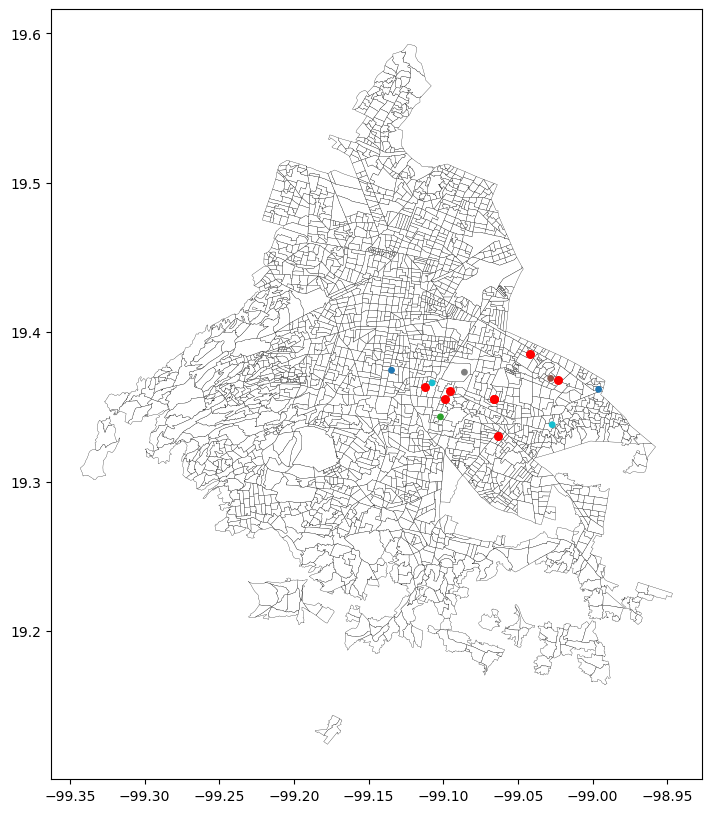

In [173]:
# Annotation: Map group 2 and the remaining candidate points.
fig,ax=plt.subplots(figsize=(12,10))
alcal.plot(ax=ax,color='white',edgecolor='black',linewidth=0.2)
grupo.plot(ax=ax,markersize=30,color='red')

dftest5.plot(ax=ax,column='pobreza',markersize=15,categorical=True)

In [174]:
# Annotation: Assign label 2 to the second exploratory group.
grupo['newgroup']=2

In [175]:
# Annotation: Create the AGEB polygon layer associated with group 2.
# Crear un DataFrame vacío para almacenar los resultados
alcgrupo2 = gpd.GeoDataFrame()

# Lista de IDs de ageb y valores de cluster de grupo
agsgru = grupo.CVE.values.tolist()
lista_cluster = grupo.newgroup.values.tolist()

# Asignar el valor del cluster a alcshp
filas_a_agregar = []
for i in range(len(alcal)):
    row2 = alcal.iloc[i]
    if row2.CVEGEO in agsgru:
        # Obtener el valor del cluster correspondiente a la ageb de alcshp
        cluster_value = lista_cluster[agsgru.index(row2.CVEGEO)]
        # Asignar el valor del cluster a la columna 'cluster' en alcshp
        row2['cluster'] = cluster_value
        # Agregar la fila a la lista de filas a agregar
        filas_a_agregar.append(row2)

# Concatenar las filas a agregar al DataFrame alcgrupo1
alcgrupo2 = pd.concat([alcgrupo2, pd.DataFrame(filas_a_agregar)], ignore_index=True)

# Mostrar el resultado
alcgrupo2=gpd.GeoDataFrame(alcgrupo2,geometry=alcgrupo2.geometry)

C:\Users\Luis Vilches\AppData\Local\Temp\ipykernel_1828\2417436692.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  row2['cluster'] = cluster_value


In [176]:
# Annotation: Propagate polygon labels using the preserved group-1 loop.
# Crear una columna 'cluster' en alcshp
alcal['cluster'] = ''

# Iterar sobre cada fila de alcgrupo1
for i in range(len(alcgrupo1)):
    row = alcgrupo1.iloc[i]
    ageb = row['CVEGEO']
    cluster_value = row['cluster']
    
    # Buscar la fila correspondiente en alcshp y asignar el valor del cluster
    alcal.loc[alcal['CVEGEO'] == ageb, 'cluster'] = cluster_value


<Axes: >

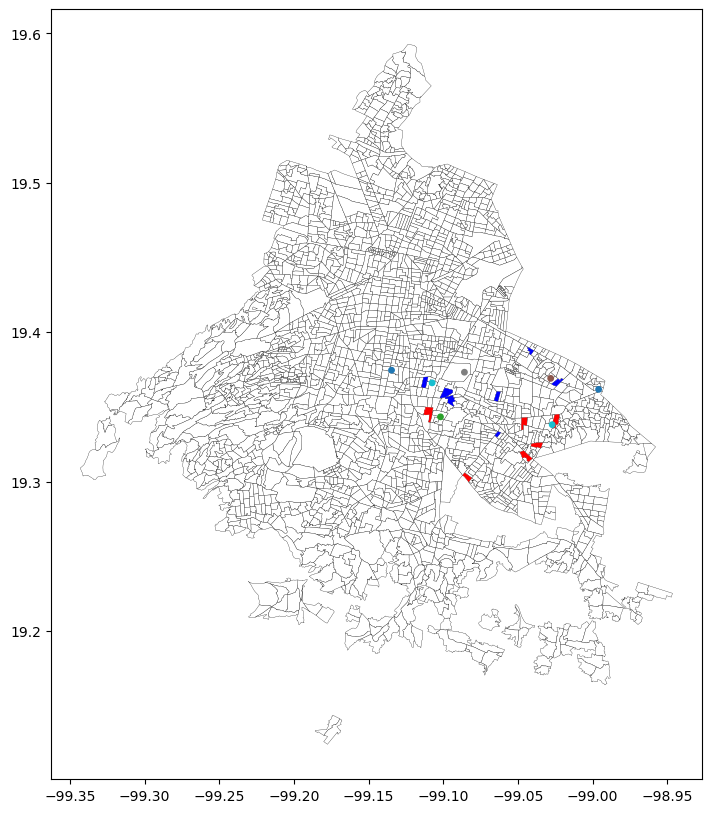

In [177]:
# Annotation: Overlay core polygon groups 1 and 2 with remaining points.
fig,ax=plt.subplots(figsize=(12,10))
alcal.plot(ax=ax,color='white',edgecolor='black',linewidth=0.2)
alcgrupo2.plot(ax=ax,color='blue')
alcgrupo1.plot(ax=ax,color='red')
dftest5.plot(ax=ax,column='pobreza',markersize=15,categorical=True)

In [178]:
# Annotation: Inspect poverty categories represented in group 2.
grupo['pobreza'].unique()

array(['(18, 34]'], dtype=object)

In [179]:
# Annotation: Mark group-2 AGEBs in the socioeconomic polygon layer.
listag=grupo['CVE'].values.tolist()

alcshppob['grupo']=''

for ageb in listag:
    # Asignar el valor 1 en 'grupo' para las filas que tienen 'CVE_AGEB_x' igual a ageb y 'alcaldia_hechos' igual a alcaldia
    alcshppob.loc[(alcshppob['CVEGEO'] == ageb), 'grupo'] = 2
    
    


alcshppob[alcshppob['grupo']==2]['Rango de pobreza (%)'].unique()

array(['(18, 34]'], dtype=object)

In [180]:
# Annotation: Extract numeric group identifiers for Queen expansion of group 2.
gruposcat=alcshppob.grupo.unique()
gruposcat = [x for x in gruposcat if isinstance(x, (int, float))]
gruposcat

[2]

In [181]:
# Annotation: Apply the Queen-neighbour extension to group 2.

agpobtlafveci2 = obtener_poligonos_vecinos_extendidos(alcshppob, w_queen, gruposcat)

C:\Users\Luis Vilches\AppData\Local\Temp\ipykernel_1828\828583937.py:50: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  fags = pd.concat([fags, dif])


In [182]:
# Annotation: Inspect the expanded group-2 polygons.
agpobtlafveci2

,CVEGEO,CVE_ENT,CVE_MUN_x,CVE_LOC,CVE_AGEB_x,geometry,Unnamed: 0,Clave de entidad,Entidad \nfederativa,CVE_MUN_y,Municipio,Rango de pobreza (%),Rango de pobreza extrema (%),CVE_AGEB_y,Clave localidad,grupo
930,0900700010708,09,007,0001,0708,"POLYGON ((-99.11000 19.36719, -99.11006 19.366...",763,9,Ciudad de México,007,Iztapalapa,"(18, 34]","[ 0, 20]",0708,1,2
1038,0900700015906,09,007,0001,5906,"POLYGON ((-99.06338 19.33353, -99.06212 19.332...",1160,9,Ciudad de México,007,Iztapalapa,"(18, 34]","[ 0, 20]",5906,1,2
1118,0900700015111,09,007,0001,5111,"POLYGON ((-99.06176 19.36006, -99.06278 19.356...",1083,9,Ciudad de México,007,Iztapalapa,"(18, 34]","[ 0, 20]",5111,1,2
1126,0900700010977,09,007,0001,0977,"POLYGON ((-99.09827 19.35646, -99.09882 19.356...",786,9,Ciudad de México,007,Iztapalapa,"(18, 34]","[ 0, 20]",0977,1,2
1138,0900700013562,09,007,0001,3562,"POLYGON ((-99.04232 19.38930, -99.04123 19.388...",956,9,Ciudad de México,007,Iztapalapa,"(18, 34]","[ 0, 20]",3562,1,2
1159,090070001077A,09,007,0001,077A,"POLYGON ((-99.01956 19.36841, -99.02147 19.366...",769,9,Ciudad de México,007,Iztapalapa,"(18, 34]","[ 0, 20]",077A,1,2
1265,0900700011227,09,007,0001,1227,"POLYGON ((-99.09335 19.35638, -99.09343 19.356...",804,9,Ciudad de México,007,Iztapalapa,"(18, 34]","[ 0, 20]",1227,1,2
967,0900700015018,09,007,0001,5018,"POLYGON ((-99.05935 19.33385, -99.05902 19.333...",1074,9,Ciudad de México,007,Iztapalapa,"(18, 34]","[ 0, 20]",5018,1,2
1099,0900700012850,09,007,0001,2850,"POLYGON ((-99.06536 19.33883, -99.06516 19.338...",912,9,Ciudad de México,007,Iztapalapa,"(18, 34]","[ 0, 20]",2850,1,2
1216,0900700015126,09,007,0001,5126,"POLYGON ((-99.06044 19.36001, -99.06054 19.359...",1084,9,Ciudad de México,007,Iztapalapa,"(18, 34]","[ 0, 20]",5126,1,2


In [183]:
# Annotation: Convert expanded group-2 polygons to a GeoDataFrame.
agpobtlafveci2=gpd.GeoDataFrame(agpobtlafveci2,geometry=agpobtlafveci2.geometry)

In [184]:
# Annotation: Inspect poverty ranges in expanded group-2 polygons.
agpobtlafveci2['Rango de pobreza (%)'].unique()

array(['(18, 34]'], dtype=object)

<Axes: >

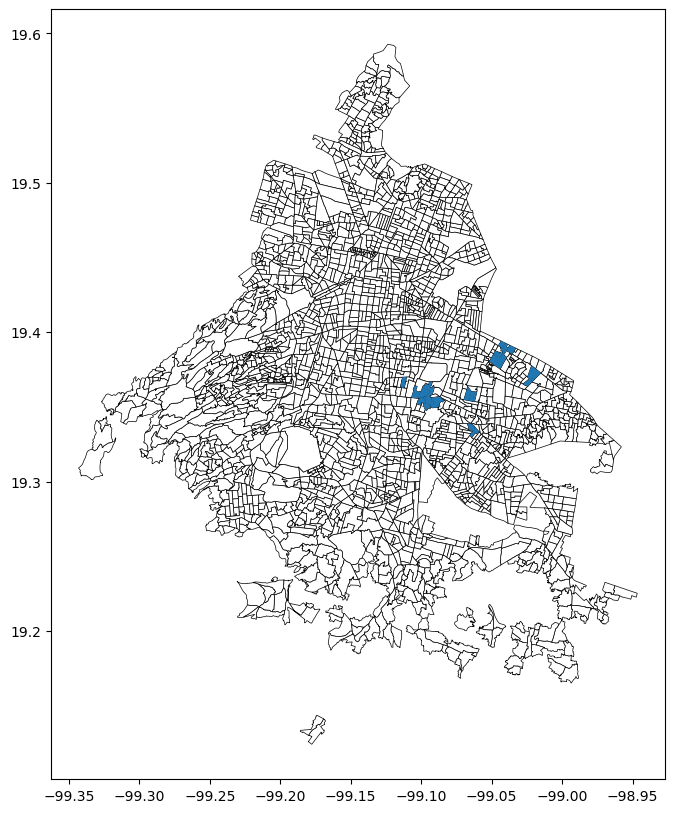

In [185]:
# Annotation: Map the Queen-expanded polygons for group 2.
fig,ax=plt.subplots(figsize=(12,10))
alcshppob.plot(ax=ax,color='white',edgecolor='black',linewidth=0.5)
#agpobtlafveci.plot(ax=ax,column='Qpob',legend=True,cmap='viridis')
#agpobtlafveci.plot(ax=ax,column='cluster',legend=True,cmap='viridis')
agpobtlafveci2.plot(ax=ax)

## 14. Exploratory group 3

The third group repeats the same workflow. Here the fallback branch of the seed function returns a `Series`; subsequent cells convert its first two positional values into geometry and poverty rather than an index and AGEB code, and then select a hard-coded root with `IDS==6`.


In [186]:
# Annotation: Count poverty categories remaining before constructing group 3.
dftest5['pobreza'].value_counts()

pobreza
(18, 34]     2
[ 0, 18]     2
(50, 70]     1
(34, 50]     1
(70, 100]    1
Name: count, dtype: int64

In [187]:
# Annotation: Repeat the remaining-point poverty counts before group 3.
dftest5['pobreza'].value_counts()

pobreza
(18, 34]     2
[ 0, 18]     2
(50, 70]     1
(34, 50]     1
(70, 100]    1
Name: count, dtype: int64

In [188]:
# Annotation: Select a seed for group 3; the fallback may return a pandas Series.
central_point = find_central_point_by_community(dftest5, dist_matrix_df)
print("Punto central:", central_point)



Índices con el valor máximo: ['0900700010483' '0900700010604' '0900700010727' '0900700011157'
 '0900700011388' '0900700012475' '0900700015003']
Punto central: geometry    POINT (-98.9960541767835 19.3617035321268)
pobreza                                       (18, 34]
CVE                                      0900700011157
IDS                                                  6
Name: 6, dtype: object


C:\ProgramData\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\ProgramData\anaconda3\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\ProgramData\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\ProgramData\anaconda3\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\ProgramData\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\ProgramData\anaconda3\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Program

In [189]:
# Annotation: Convert the returned Series positionally, producing geometry and poverty values.
central_point=[central_point[0],central_point[1]]
central_point

C:\Users\Luis Vilches\AppData\Local\Temp\ipykernel_1828\610654960.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  central_point=[central_point[0],central_point[1]]


[<POINT (-98.996 19.362)>, '(18, 34]']

In [191]:
# Annotation: Select a hard-coded group-3 root with IDS equal to 6.
root=dftest5[dftest5['IDS']==6]
root

,geometry,pobreza,CVE,IDS
6,POINT (-98.99605 19.36170),"(18, 34]",0900700011157,6


<Axes: >

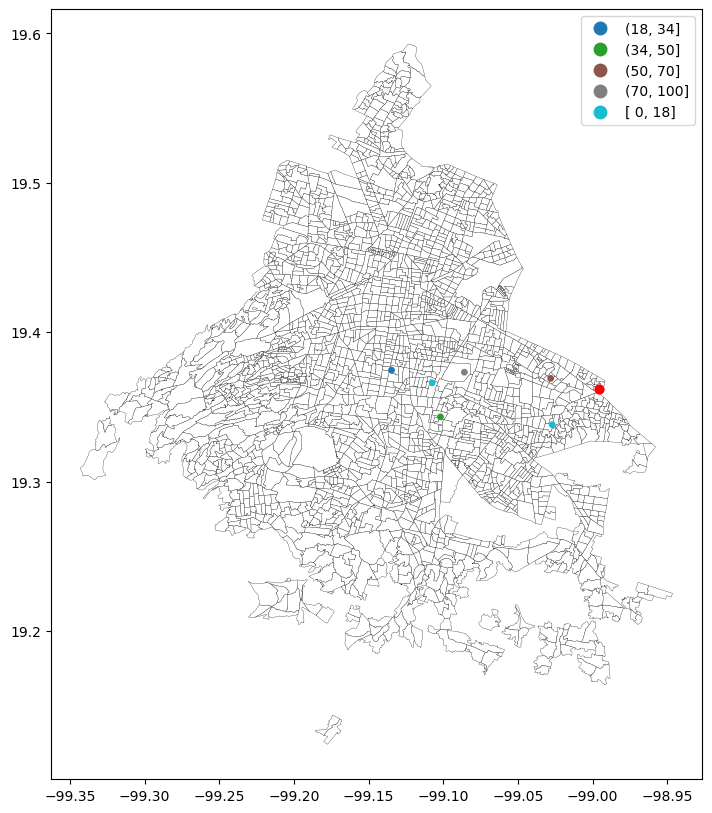

In [192]:
# Annotation: Map the hard-coded group-3 root over remaining points.
fig,ax=plt.subplots(figsize=(12,10))
alcal.plot(ax=ax,color='white',edgecolor='black',linewidth=0.2)
dftest5.plot(ax=ax,column='pobreza',markersize=15,legend=True,categorical=True)
root.plot(ax=ax,markersize=40,color='red')


In [193]:
# Annotation: Initialize the group-3 GeoDataFrame.
grupo=gpd.GeoDataFrame(root,geometry=root.geometry)
grupo.columns

Index(['geometry', 'pobreza', 'CVE', 'IDS'], dtype='object')

In [194]:
# Annotation: Inspect the group-3 root poverty category.
grupo['pobreza']

6    (18, 34]
Name: pobreza, dtype: object

In [195]:
# Annotation: Create the group-3 candidate set using the nominal central-point index.
dftest6=dftest5[dftest5['IDS'] != central_point[0]]
dftest6

,geometry,pobreza,CVE,IDS
4,POINT (-99.02814 19.36908),"(50, 70]",0900700010604,4
6,POINT (-98.99605 19.36170),"(18, 34]",0900700011157,6
7,POINT (-99.10193 19.34331),"(34, 50]",0900700011388,7
9,POINT (-99.10751 19.36607),"[ 0, 18]",0900700010727,9
12,POINT (-99.13471 19.37457),"(18, 34]",0900700010483,12
18,POINT (-99.02713 19.33807),"[ 0, 18]",0900700015003,18
19,POINT (-99.08589 19.37319),"(70, 100]",0900700012475,19


In [196]:
# Annotation: Expand group 3 using equal poverty and the mean-distance threshold.
import pandas as pd

# Supongamos que tienes los DataFrames dftest2 y grupo, y la matriz de distancias dist_matrix_df ya definidos
# También asumiendo que lim_inf_pob, lim_sup_pob, y mean_distance ya están definidos


# Itera sobre las filas de dftest2
for i in range(len(dftest6)):
    row2 = dftest6.iloc[i]
    ind2 = row2['IDS']
    #pob2 = row2['poblacion']
    rangpob2 = row2['pobreza']
    
    for j in range(len(grupo)):
        row1 = grupo.iloc[j]
        ind1 = row1['IDS']
        #pob1 = row1['poblacion']
        rangpob = row1['pobreza']
        
        distance_value = dist_matrix_df.loc[ind1, ind2]
        if (distance_value <= mean_distance) and (rangpob == rangpob2):
            
            grupo = pd.concat([grupo, pd.DataFrame([row2])], ignore_index=True)
            break  # Salir del bucle interno después de agregar la fila

print(grupo)



                     geometry   pobreza            CVE  IDS
0  POINT (-98.99605 19.36170)  (18, 34]  0900700011157    6
1  POINT (-98.99605 19.36170)  (18, 34]  0900700011157    6


In [197]:
# Annotation: Inspect poverty categories represented in group 3.
grupo['pobreza'].unique()

array(['(18, 34]'], dtype=object)

In [198]:
# Annotation: Store group-3 identifiers and report group size.
listaids=grupo['IDS'].values.tolist()
len(grupo)

2

In [199]:
# Annotation: Remove group-3 members from the remaining candidates.
dftest7 = dftest6[~dftest6['IDS'].isin(listaids)]
dftest7['pobreza'].unique()

array(['(50, 70]', '(34, 50]', '[ 0, 18]', '(18, 34]', '(70, 100]'],
      dtype=object)

In [200]:
# Annotation: Report the final size of group 3.
len(grupo)

2

<Axes: >

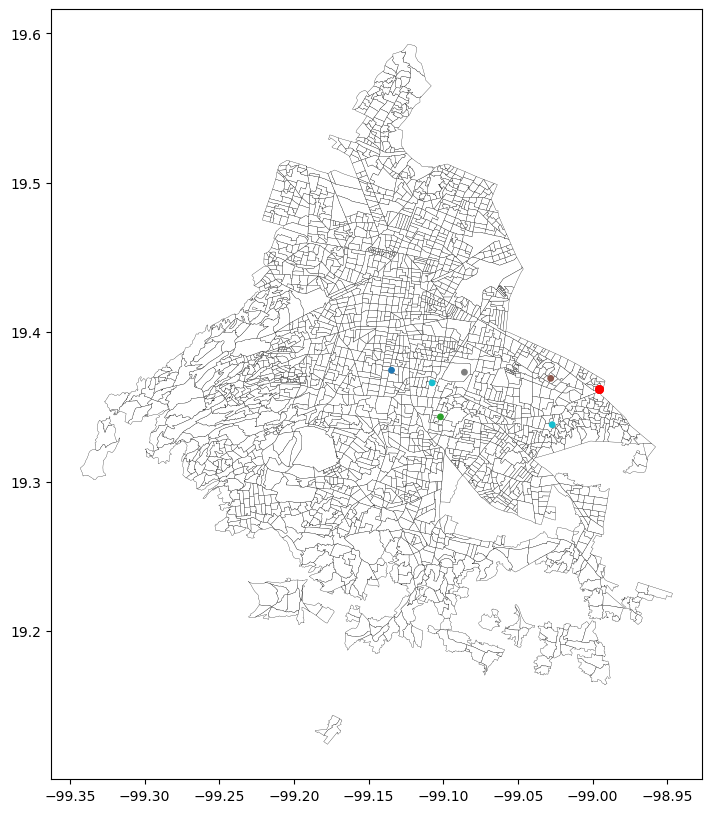

In [201]:
# Annotation: Map group 3 and remaining points.
fig,ax=plt.subplots(figsize=(12,10))
alcal.plot(ax=ax,color='white',edgecolor='black',linewidth=0.2)
grupo.plot(ax=ax,markersize=30,color='red')

dftest7.plot(ax=ax,column='pobreza',markersize=15,categorical=True)

In [202]:
# Annotation: Assign label 3 to the third exploratory group.
grupo['newgroup']=3

In [203]:
# Annotation: Create the AGEB polygon layer associated with group 3.
# Crear un DataFrame vacío para almacenar los resultados
alcgrupo3 = gpd.GeoDataFrame()

# Lista de IDs de ageb y valores de cluster de grupo
agsgru = grupo.CVE.values.tolist()
lista_cluster = grupo.newgroup.values.tolist()

# Asignar el valor del cluster a alcshp
filas_a_agregar = []
for i in range(len(alcal)):
    row2 = alcal.iloc[i]
    if row2.CVEGEO in agsgru:
        # Obtener el valor del cluster correspondiente a la ageb de alcshp
        cluster_value = lista_cluster[agsgru.index(row2.CVEGEO)]
        # Asignar el valor del cluster a la columna 'cluster' en alcshp
        row2['cluster'] = cluster_value
        # Agregar la fila a la lista de filas a agregar
        filas_a_agregar.append(row2)

# Concatenar las filas a agregar al DataFrame alcgrupo1
alcgrupo3 = pd.concat([alcgrupo3, pd.DataFrame(filas_a_agregar)], ignore_index=True)

# Mostrar el resultado
alcgrupo3=gpd.GeoDataFrame(alcgrupo3,geometry=alcgrupo3.geometry)

C:\Users\Luis Vilches\AppData\Local\Temp\ipykernel_1828\3921591120.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  row2['cluster'] = cluster_value


In [204]:
# Annotation: Propagate group-3 labels to the complete AGEB layer.
# Crear una columna 'cluster' en alcshp
alcal['cluster'] = ''

# Iterar sobre cada fila de alcgrupo1
for i in range(len(alcgrupo3)):
    row = alcgrupo3.iloc[i]
    ageb = row['CVEGEO']
    cluster_value = row['cluster']
    
    # Buscar la fila correspondiente en alcshp y asignar el valor del cluster
    alcal.loc[alcal['CVEGEO'] == ageb, 'cluster'] = cluster_value


<Axes: >

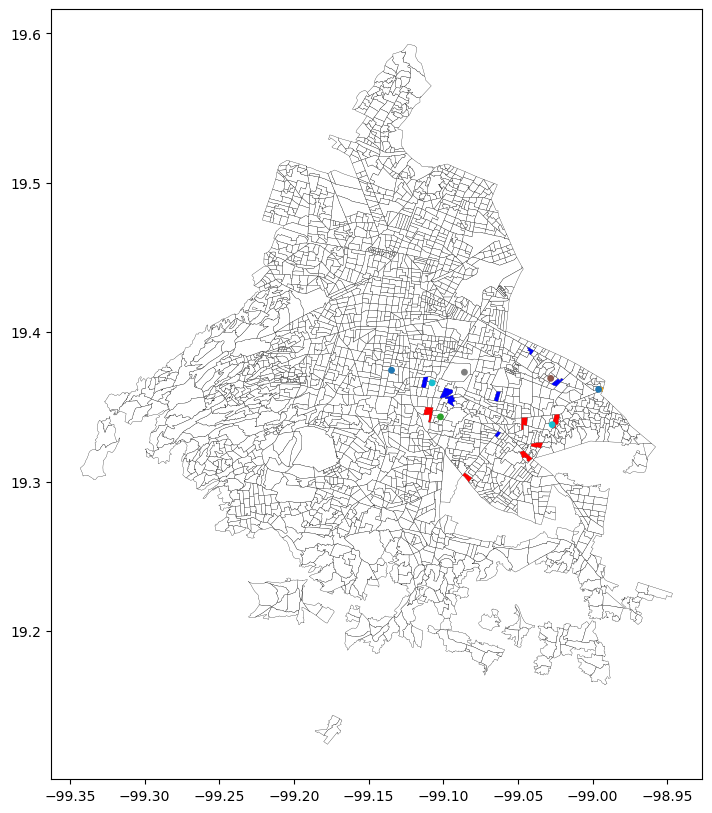

In [205]:
# Annotation: Overlay polygon groups 1–3 with remaining points.
fig,ax=plt.subplots(figsize=(12,10))
alcal.plot(ax=ax,color='white',edgecolor='black',linewidth=0.2)
alcgrupo2.plot(ax=ax,color='blue')
alcgrupo1.plot(ax=ax,color='red')
alcgrupo3.plot(ax=ax,color='ORANGE')
dftest5.plot(ax=ax,column='pobreza',markersize=15,categorical=True)

In [206]:
# Annotation: Inspect poverty categories represented in group 3.
grupo['pobreza'].unique()

array(['(18, 34]'], dtype=object)

In [207]:
# Annotation: Mark group-3 AGEBs in the socioeconomic polygon layer.
listag=grupo['CVE'].values.tolist()

alcshppob['grupo']=''

for ageb in listag:
    # Asignar el valor 1 en 'grupo' para las filas que tienen 'CVE_AGEB_x' igual a ageb y 'alcaldia_hechos' igual a alcaldia
    alcshppob.loc[(alcshppob['CVEGEO'] == ageb), 'grupo'] = 3
    
    


alcshppob[alcshppob['grupo']==3]['Rango de pobreza (%)'].unique()

array(['(18, 34]'], dtype=object)

In [208]:
# Annotation: Extract numeric group identifiers for Queen expansion of group 3.
gruposcat=alcshppob.grupo.unique()
gruposcat = [x for x in gruposcat if isinstance(x, (int, float))]
gruposcat

[3]

In [209]:
# Annotation: Apply the Queen-neighbour extension to group 3.

agpobtlafveci3 = obtener_poligonos_vecinos_extendidos(alcshppob, w_queen, gruposcat)

C:\Users\Luis Vilches\AppData\Local\Temp\ipykernel_1828\828583937.py:50: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  fags = pd.concat([fags, dif])


In [210]:
# Annotation: Inspect expanded group-3 polygons.
agpobtlafveci3

,CVEGEO,CVE_ENT,CVE_MUN_x,CVE_LOC,CVE_AGEB_x,geometry,Unnamed: 0,Clave de entidad,Entidad \nfederativa,CVE_MUN_y,Municipio,Rango de pobreza (%),Rango de pobreza extrema (%),CVE_AGEB_y,Clave localidad,grupo
1029,0900700011157,09,007,0001,1157,"POLYGON ((-98.99479 19.36369, -98.99479 19.363...",799,9,Ciudad de México,007,Iztapalapa,"(18, 34]","[ 0, 20]",1157,1,3


In [211]:
# Annotation: Convert expanded group-3 polygons to a GeoDataFrame.
agpobtlafveci3=gpd.GeoDataFrame(agpobtlafveci3,geometry=agpobtlafveci3.geometry)

In [212]:
# Annotation: Inspect poverty ranges in expanded group-3 polygons.
agpobtlafveci3['Rango de pobreza (%)'].unique()

array(['(18, 34]'], dtype=object)

<Axes: >

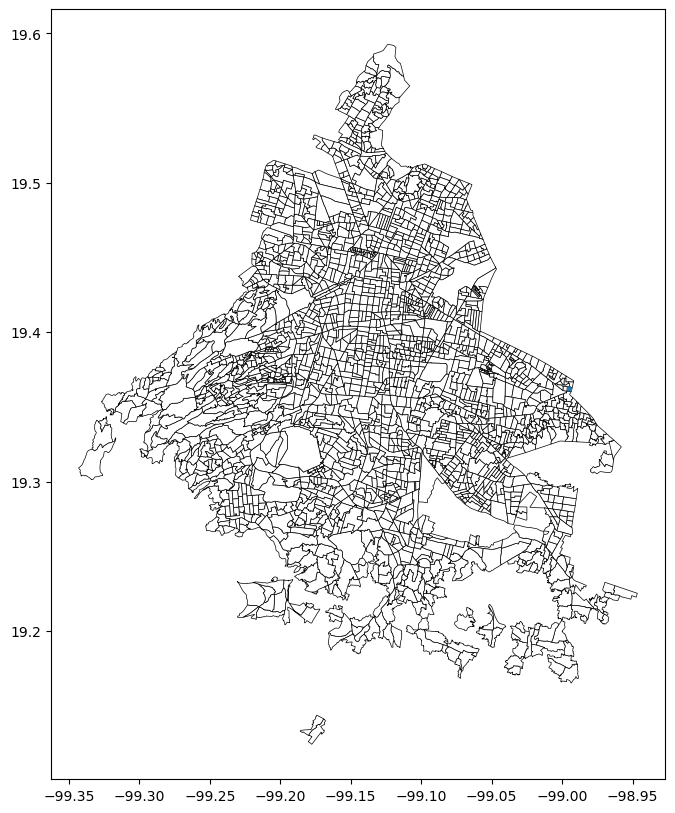

In [213]:
# Annotation: Map the Queen-expanded polygons for group 3.
fig,ax=plt.subplots(figsize=(12,10))
alcshppob.plot(ax=ax,color='white',edgecolor='black',linewidth=0.5)
#agpobtlafveci.plot(ax=ax,column='Qpob',legend=True,cmap='viridis')
#agpobtlafveci.plot(ax=ax,column='cluster',legend=True,cmap='viridis')
agpobtlafveci3.plot(ax=ax)

## 15. Exploratory group 4

The fourth group again uses a hard-coded root (`IDS==7`). One cell creates `dftest8` but displays `dftest4`, which is a stale intermediate from a prior group.


In [214]:
# Annotation: Count poverty categories remaining before constructing group 4.
dftest7['pobreza'].value_counts()

pobreza
[ 0, 18]     2
(50, 70]     1
(34, 50]     1
(18, 34]     1
(70, 100]    1
Name: count, dtype: int64

In [215]:
# Annotation: Select a seed for group 4; the fallback again returns a Series.
central_point = find_central_point_by_community(dftest7, dist_matrix_df)
print("Punto central:", central_point)



Índices con el valor máximo: ['0900700010483' '0900700010604' '0900700010727' '0900700011388'
 '0900700012475' '0900700015003']
Punto central: geometry    POINT (-99.1019321401216 19.3433100192743)
pobreza                                       (34, 50]
CVE                                      0900700011388
IDS                                                  7
Name: 7, dtype: object


C:\ProgramData\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\ProgramData\anaconda3\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\ProgramData\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\ProgramData\anaconda3\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\ProgramData\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\ProgramData\anaconda3\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Program

In [216]:
# Annotation: Convert the seed Series positionally into geometry and poverty values.
central_point=[central_point[0],central_point[1]]
central_point

C:\Users\Luis Vilches\AppData\Local\Temp\ipykernel_1828\610654960.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  central_point=[central_point[0],central_point[1]]


[<POINT (-99.102 19.343)>, '(34, 50]']

In [217]:
# Annotation: Select a hard-coded group-4 root with IDS equal to 7.
root=dftest7[dftest7['IDS']==7]
root

,geometry,pobreza,CVE,IDS
7,POINT (-99.10193 19.34331),"(34, 50]",0900700011388,7


<Axes: >

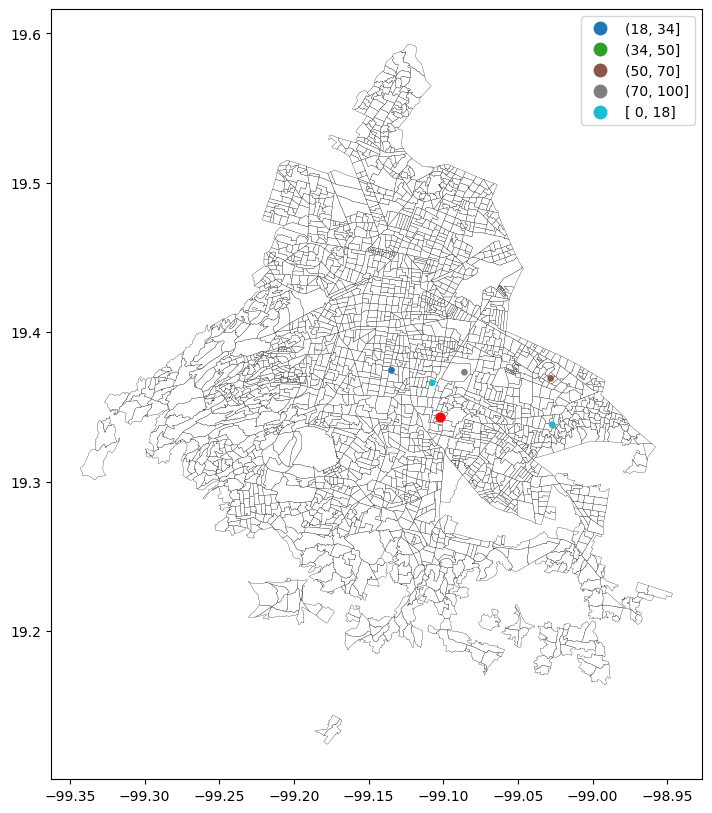

In [218]:
# Annotation: Map the group-4 root over remaining points.
fig,ax=plt.subplots(figsize=(12,10))
alcal.plot(ax=ax,color='white',edgecolor='black',linewidth=0.2)
dftest7.plot(ax=ax,column='pobreza',markersize=15,legend=True,categorical=True)
root.plot(ax=ax,markersize=40,color='red')


In [219]:
# Annotation: Initialize the group-4 GeoDataFrame.
grupo=gpd.GeoDataFrame(root,geometry=root.geometry)
grupo.columns

Index(['geometry', 'pobreza', 'CVE', 'IDS'], dtype='object')

In [220]:
# Annotation: Inspect the group-4 root poverty category.
grupo['pobreza']

7    (34, 50]
Name: pobreza, dtype: object

In [221]:
# Annotation: Display the previously stored poverty-category list.
listapobreza

['(34, 50]']

In [224]:
# Annotation: Create `dftest8` after root removal but display the stale `dftest4` object.
dftest8=dftest7[dftest7['IDS'] != 7]
dftest4

,geometry,pobreza,CVE,IDS
4,POINT (-99.02814 19.36908),"(50, 70]",0900700010604,4
6,POINT (-98.99605 19.36170),"(18, 34]",0900700011157,6
7,POINT (-99.10193 19.34331),"(34, 50]",0900700011388,7
9,POINT (-99.10751 19.36607),"[ 0, 18]",0900700010727,9
10,POINT (-99.06314 19.33075),"(18, 34]",0900700015906,10
12,POINT (-99.13471 19.37457),"(18, 34]",0900700010483,12
14,POINT (-99.06581 19.35500),"(18, 34]",0900700015111,14
16,POINT (-99.04185 19.38523),"(18, 34]",0900700013562,16
18,POINT (-99.02713 19.33807),"[ 0, 18]",0900700015003,18
19,POINT (-99.08589 19.37319),"(70, 100]",0900700012475,19


In [225]:
# Annotation: Expand group 4 using equal poverty and the mean-distance threshold.
import pandas as pd

# Supongamos que tienes los DataFrames dftest2 y grupo, y la matriz de distancias dist_matrix_df ya definidos
# También asumiendo que lim_inf_pob, lim_sup_pob, y mean_distance ya están definidos


# Itera sobre las filas de dftest2
for i in range(len(dftest8)):
    row2 = dftest8.iloc[i]
    ind2 = row2['IDS']
    #pob2 = row2['poblacion']
    rangpob2 = row2['pobreza']
    
    for j in range(len(grupo)):
        row1 = grupo.iloc[j]
        ind1 = row1['IDS']
        #pob1 = row1['poblacion']
        rangpob = row1['pobreza']
        
        distance_value = dist_matrix_df.loc[ind1, ind2]
        if (distance_value <= mean_distance) and (rangpob == rangpob2):
            
            grupo = pd.concat([grupo, pd.DataFrame([row2])], ignore_index=True)
            break  # Salir del bucle interno después de agregar la fila

print(grupo)



                     geometry   pobreza            CVE  IDS
0  POINT (-99.10193 19.34331)  (34, 50]  0900700011388    7
1  POINT (-99.10193 19.34331)  (34, 50]  0900700011388    7


In [226]:
# Annotation: Inspect poverty categories represented in group 4.
grupo['pobreza'].unique()

array(['(34, 50]'], dtype=object)

In [227]:
# Annotation: Store group-4 identifiers and report group size.
listaids=grupo['IDS'].values.tolist()
len(grupo)

2

In [228]:
# Annotation: Remove group-4 members from the remaining candidates.
dftest9 = dftest8[~dftest8['IDS'].isin(listaids)]
dftest9['pobreza'].unique()

array(['(50, 70]', '[ 0, 18]', '(18, 34]', '(70, 100]'], dtype=object)

In [229]:
# Annotation: Report the final size of group 4.
len(grupo)

2

<Axes: >

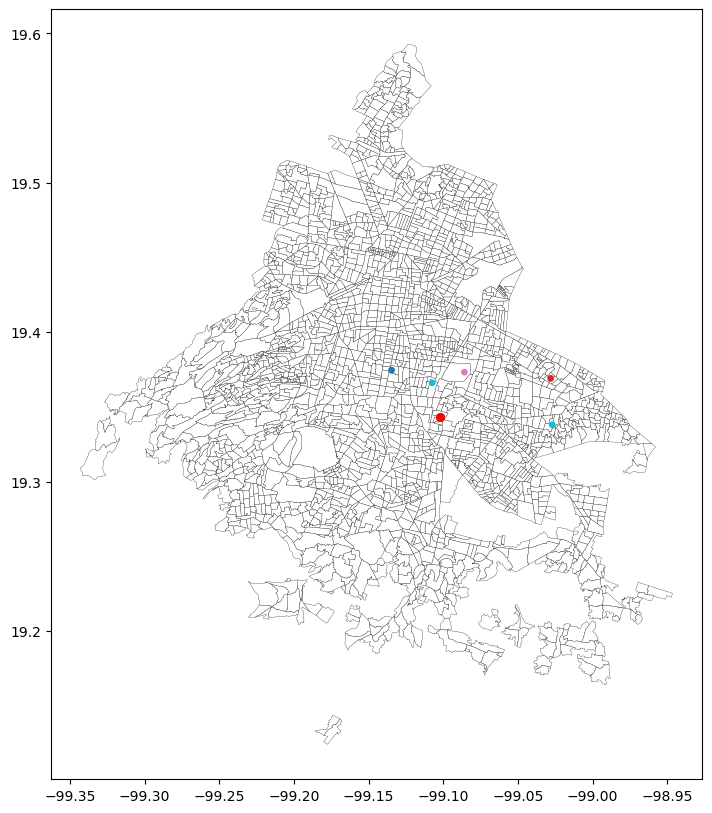

In [230]:
# Annotation: Map group 4 and remaining points.
fig,ax=plt.subplots(figsize=(12,10))
alcal.plot(ax=ax,color='white',edgecolor='black',linewidth=0.2)
grupo.plot(ax=ax,markersize=30,color='red')

dftest9.plot(ax=ax,column='pobreza',markersize=15,categorical=True)

In [231]:
# Annotation: Assign label 4 to the fourth exploratory group.
grupo['newgroup']=4

In [232]:
# Annotation: Create the AGEB polygon layer associated with group 4.
# Crear un DataFrame vacío para almacenar los resultados
alcgrupo4= gpd.GeoDataFrame()

# Lista de IDs de ageb y valores de cluster de grupo
agsgru = grupo.CVE.values.tolist()
lista_cluster = grupo.newgroup.values.tolist()

# Asignar el valor del cluster a alcshp
filas_a_agregar = []
for i in range(len(alcal)):
    row2 = alcal.iloc[i]
    if row2.CVEGEO in agsgru:
        # Obtener el valor del cluster correspondiente a la ageb de alcshp
        cluster_value = lista_cluster[agsgru.index(row2.CVEGEO)]
        # Asignar el valor del cluster a la columna 'cluster' en alcshp
        row2['cluster'] = cluster_value
        # Agregar la fila a la lista de filas a agregar
        filas_a_agregar.append(row2)

# Concatenar las filas a agregar al DataFrame alcgrupo1
alcgrupo4 = pd.concat([alcgrupo4, pd.DataFrame(filas_a_agregar)], ignore_index=True)

# Mostrar el resultado
alcgrupo4=gpd.GeoDataFrame(alcgrupo4,geometry=alcgrupo4.geometry)

C:\Users\Luis Vilches\AppData\Local\Temp\ipykernel_1828\761857396.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  row2['cluster'] = cluster_value


In [233]:
# Annotation: Propagate group-4 labels to the complete AGEB layer.
# Crear una columna 'cluster' en alcshp
alcal['cluster'] = ''

# Iterar sobre cada fila de alcgrupo1
for i in range(len(alcgrupo4)):
    row = alcgrupo4.iloc[i]
    ageb = row['CVEGEO']
    cluster_value = row['cluster']
    
    # Buscar la fila correspondiente en alcshp y asignar el valor del cluster
    alcal.loc[alcal['CVEGEO'] == ageb, 'cluster'] = cluster_value


<Axes: >

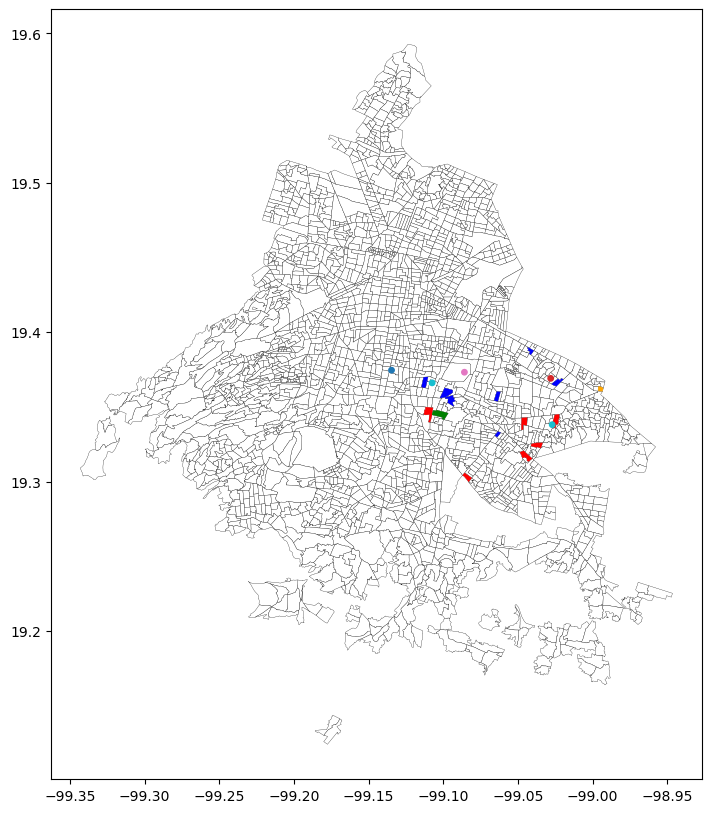

In [234]:
# Annotation: Overlay polygon groups 1–4 with remaining points.
fig,ax=plt.subplots(figsize=(12,10))
alcal.plot(ax=ax,color='white',edgecolor='black',linewidth=0.2)
alcgrupo2.plot(ax=ax,color='blue')
alcgrupo1.plot(ax=ax,color='red')
alcgrupo3.plot(ax=ax,color='orange')
alcgrupo4.plot(ax=ax,color='green')
dftest9.plot(ax=ax,column='pobreza',markersize=15,categorical=True)

In [235]:
# Annotation: Inspect poverty categories represented in group 4.
grupo['pobreza'].unique()

array(['(34, 50]'], dtype=object)

In [236]:
# Annotation: Mark group-4 AGEBs in the socioeconomic polygon layer.
listag=grupo['CVE'].values.tolist()

alcshppob['grupo']=''

for ageb in listag:
    # Asignar el valor 1 en 'grupo' para las filas que tienen 'CVE_AGEB_x' igual a ageb y 'alcaldia_hechos' igual a alcaldia
    alcshppob.loc[(alcshppob['CVEGEO'] == ageb), 'grupo'] = 4
    
    


alcshppob[alcshppob['grupo']==4]['Rango de pobreza (%)'].unique()

array(['(34, 50]'], dtype=object)

In [237]:
# Annotation: Extract numeric group identifiers for Queen expansion of group 4.
gruposcat=alcshppob.grupo.unique()
gruposcat = [x for x in gruposcat if isinstance(x, (int, float))]
gruposcat

[4]

In [238]:
# Annotation: Apply the Queen-neighbour extension to group 4.

agpobtlafveci4 = obtener_poligonos_vecinos_extendidos(alcshppob, w_queen, gruposcat)

C:\Users\Luis Vilches\AppData\Local\Temp\ipykernel_1828\828583937.py:50: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  fags = pd.concat([fags, dif])


In [239]:
# Annotation: Inspect expanded group-4 polygons.
agpobtlafveci4

,CVEGEO,CVE_ENT,CVE_MUN_x,CVE_LOC,CVE_AGEB_x,geometry,Unnamed: 0,Clave de entidad,Entidad \nfederativa,CVE_MUN_y,Municipio,Rango de pobreza (%),Rango de pobreza extrema (%),CVE_AGEB_y,Clave localidad,grupo
1237,0900700011388,09,007,0001,1388,"POLYGON ((-99.10225 19.34726, -99.10195 19.347...",817,9,Ciudad de México,007,Iztapalapa,"(34, 50]","[ 0, 20]",1388,1,4
998,0900700011369,09,007,0001,1369,"POLYGON ((-99.11084 19.34979, -99.11022 19.349...",816,9,Ciudad de México,007,Iztapalapa,"(34, 50]","[ 0, 20]",1369,1,4
1030,0900700011208,09,007,0001,1208,"POLYGON ((-99.10678 19.35619, -99.10576 19.356...",803,9,Ciudad de México,007,Iztapalapa,"(34, 50]","[ 0, 20]",1208,1,4
1221,0900700013825,09,007,0001,3825,"POLYGON ((-99.10105 19.34189, -99.10096 19.341...",979,9,Ciudad de México,007,Iztapalapa,"(34, 50]","[ 0, 20]",3825,1,4


In [240]:
# Annotation: Convert expanded group-4 polygons to a GeoDataFrame.
agpobtlafveci4=gpd.GeoDataFrame(agpobtlafveci4,geometry=agpobtlafveci4.geometry)

In [241]:
# Annotation: Inspect poverty ranges in expanded group-4 polygons.
agpobtlafveci4['Rango de pobreza (%)'].unique()

array(['(34, 50]'], dtype=object)

<Axes: >

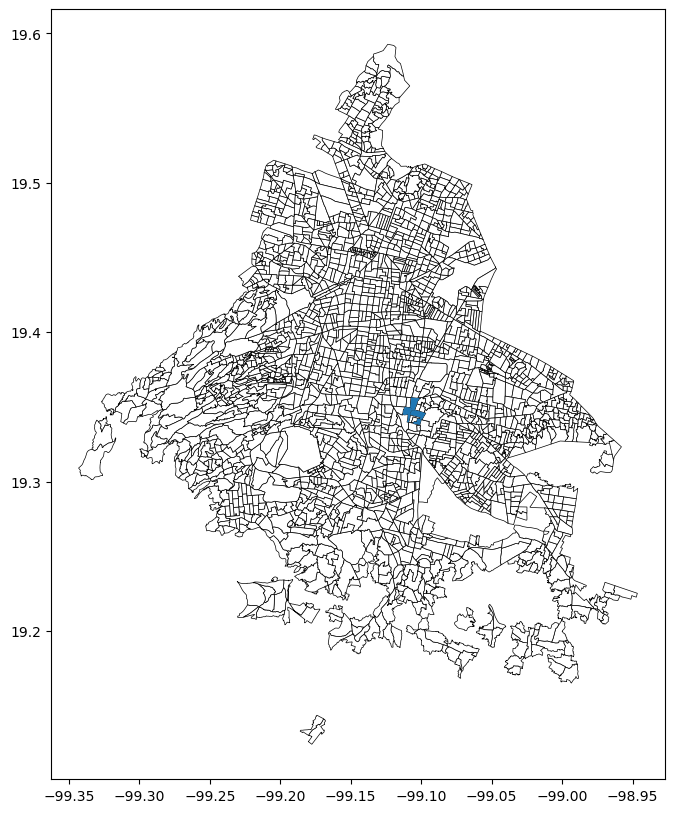

In [242]:
# Annotation: Map the Queen-expanded polygons for group 4.
fig,ax=plt.subplots(figsize=(12,10))
alcshppob.plot(ax=ax,color='white',edgecolor='black',linewidth=0.5)
#agpobtlafveci.plot(ax=ax,column='Qpob',legend=True,cmap='viridis')
#agpobtlafveci.plot(ax=ax,column='cluster',legend=True,cmap='viridis')
agpobtlafveci4.plot(ax=ax)

## 16. Exploratory group 5

The fifth group uses a geometry-based root after the seed function returns a `Series`. The polygon-construction cells incorrectly concatenate and reconvert `alcgrupo4`, so the stored `alcgrupo5` does not independently represent group 5.


In [243]:
# Annotation: Count poverty categories remaining before constructing group 5.
dftest9['pobreza'].value_counts()

pobreza
[ 0, 18]     2
(50, 70]     1
(18, 34]     1
(70, 100]    1
Name: count, dtype: int64

In [244]:
# Annotation: Select a seed for group 5.
central_point = find_central_point_by_community(dftest9, dist_matrix_df)
print("Punto central:", central_point)



Índices con el valor máximo: ['0900700010483' '0900700010604' '0900700010727' '0900700012475'
 '0900700015003']
Punto central: geometry    POINT (-99.1347082883986 19.3745696178901)
pobreza                                       (18, 34]
CVE                                      0900700010483
IDS                                                 12
Name: 12, dtype: object


C:\ProgramData\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\ProgramData\anaconda3\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\ProgramData\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\ProgramData\anaconda3\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\ProgramData\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\ProgramData\anaconda3\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Program

In [245]:
# Annotation: Display the Series returned by the seed-selection fallback.
central_point

geometry    POINT (-99.1347082883986 19.3745696178901)
pobreza                                       (18, 34]
CVE                                      0900700010483
IDS                                                 12
Name: 12, dtype: object

In [246]:
# Annotation: Convert the seed Series positionally into geometry and poverty values.
central_point=[central_point[0],central_point[1]]
central_point

C:\Users\Luis Vilches\AppData\Local\Temp\ipykernel_1828\610654960.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  central_point=[central_point[0],central_point[1]]


[<POINT (-99.135 19.375)>, '(18, 34]']

In [247]:
# Annotation: Select the group-5 root by geometry.
root=dftest9[dftest9['geometry']==central_point[0]]
root

,geometry,pobreza,CVE,IDS
12,POINT (-99.13471 19.37457),"(18, 34]",0900700010483,12


<Axes: >

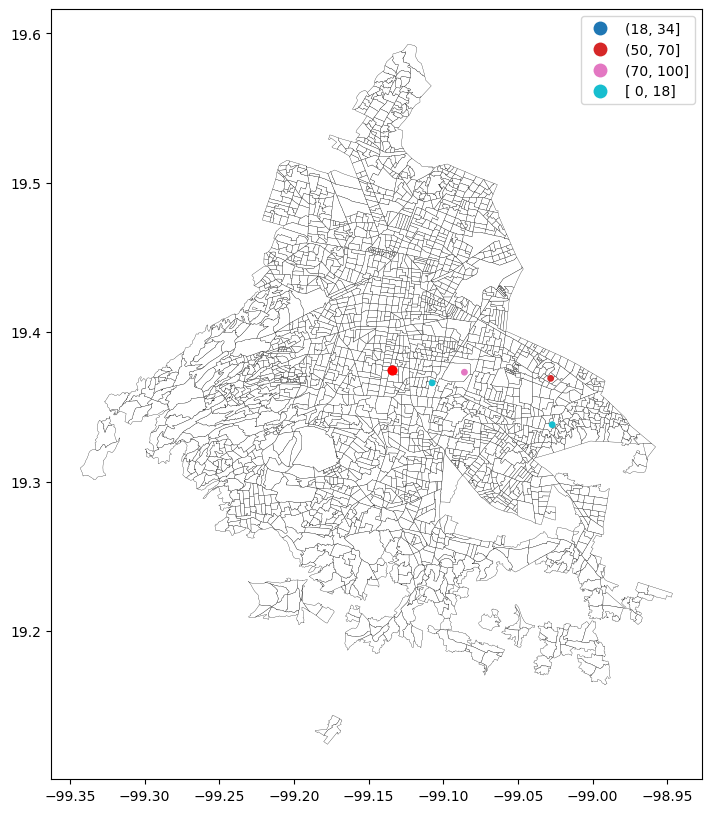

In [248]:
# Annotation: Map the group-5 root over remaining points.
fig,ax=plt.subplots(figsize=(12,10))
alcal.plot(ax=ax,color='white',edgecolor='black',linewidth=0.2)
dftest9.plot(ax=ax,column='pobreza',markersize=15,legend=True,categorical=True)
root.plot(ax=ax,markersize=40,color='red')


In [249]:
# Annotation: Initialize the group-5 GeoDataFrame.
grupo=gpd.GeoDataFrame(root,geometry=root.geometry)
grupo.columns

Index(['geometry', 'pobreza', 'CVE', 'IDS'], dtype='object')

In [250]:
# Annotation: Inspect the group-5 root poverty category.
grupo['pobreza']

12    (18, 34]
Name: pobreza, dtype: object

In [251]:
# Annotation: Display the previously stored poverty-category list.
listapobreza

['(34, 50]']

In [252]:
# Annotation: Remove the group-5 root using geometry equality.
dftest10=dftest9[dftest9['geometry'] != central_point[0]]
dftest10

,geometry,pobreza,CVE,IDS
4,POINT (-99.02814 19.36908),"(50, 70]",0900700010604,4
9,POINT (-99.10751 19.36607),"[ 0, 18]",0900700010727,9
18,POINT (-99.02713 19.33807),"[ 0, 18]",0900700015003,18
19,POINT (-99.08589 19.37319),"(70, 100]",0900700012475,19


In [253]:
# Annotation: Expand group 5 using equal poverty and the mean-distance threshold.
import pandas as pd

# Supongamos que tienes los DataFrames dftest2 y grupo, y la matriz de distancias dist_matrix_df ya definidos
# También asumiendo que lim_inf_pob, lim_sup_pob, y mean_distance ya están definidos


# Itera sobre las filas de dftest2
for i in range(len(dftest10)):
    row2 = dftest10.iloc[i]
    ind2 = row2['IDS']
    #pob2 = row2['poblacion']
    rangpob2 = row2['pobreza']
    
    for j in range(len(grupo)):
        row1 = grupo.iloc[j]
        ind1 = row1['IDS']
        #pob1 = row1['poblacion']
        rangpob = row1['pobreza']
        
        distance_value = dist_matrix_df.loc[ind1, ind2]
        if (distance_value <= mean_distance) and (rangpob == rangpob2):
            
            grupo = pd.concat([grupo, pd.DataFrame([row2])], ignore_index=True)
            break  # Salir del bucle interno después de agregar la fila

print(grupo)



                      geometry   pobreza            CVE  IDS
12  POINT (-99.13471 19.37457)  (18, 34]  0900700010483   12


In [254]:
# Annotation: Inspect poverty categories represented in group 5.
grupo['pobreza'].unique()

array(['(18, 34]'], dtype=object)

In [255]:
# Annotation: Store group-5 identifiers and report group size.
listaids=grupo['IDS'].values.tolist()
len(grupo)

1

In [256]:
# Annotation: Remove group-5 members from the remaining candidates.
dftest11 = dftest10[~dftest10['IDS'].isin(listaids)]
dftest11['pobreza'].unique()

array(['(50, 70]', '[ 0, 18]', '(70, 100]'], dtype=object)

In [257]:
# Annotation: Report the final size of group 5.
len(grupo)

1

<Axes: >

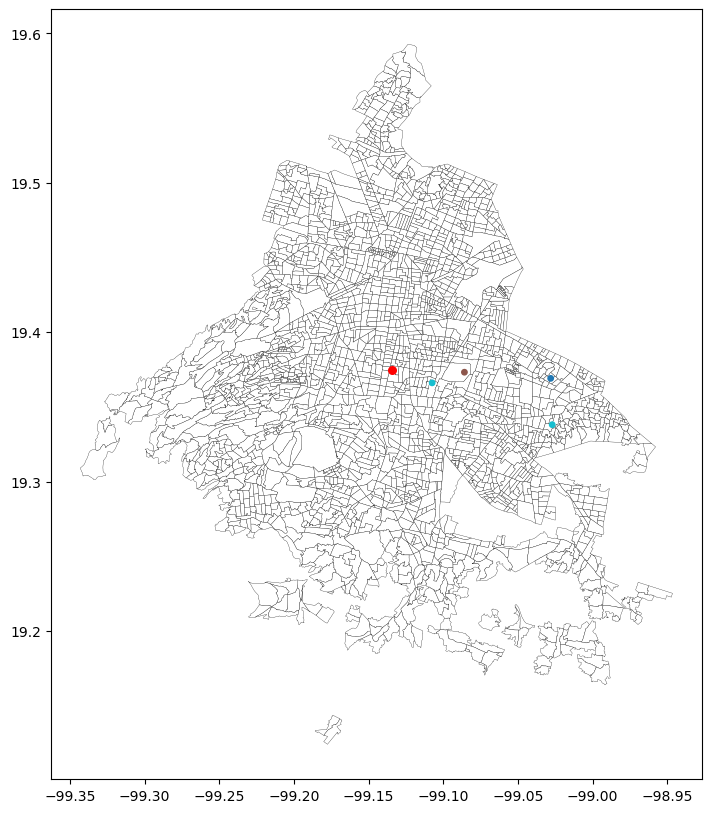

In [258]:
# Annotation: Map group 5 and remaining points.
fig,ax=plt.subplots(figsize=(12,10))
alcal.plot(ax=ax,color='white',edgecolor='black',linewidth=0.2)
grupo.plot(ax=ax,markersize=30,color='red')

dftest11.plot(ax=ax,column='pobreza',markersize=15,categorical=True)

In [259]:
# Annotation: Assign label 5 to the fifth exploratory group.
grupo['newgroup']=5

In [260]:
# Annotation: Attempt to create group-5 polygons but concatenate and reconvert group-4 objects.
# Crear un DataFrame vacío para almacenar los resultados
alcgrupo5= gpd.GeoDataFrame()

# Lista de IDs de ageb y valores de cluster de grupo
agsgru = grupo.CVE.values.tolist()
lista_cluster = grupo.newgroup.values.tolist()

# Asignar el valor del cluster a alcshp
filas_a_agregar = []
for i in range(len(alcal)):
    row2 = alcal.iloc[i]
    if row2.CVEGEO in agsgru:
        # Obtener el valor del cluster correspondiente a la ageb de alcshp
        cluster_value = lista_cluster[agsgru.index(row2.CVEGEO)]
        # Asignar el valor del cluster a la columna 'cluster' en alcshp
        row2['cluster'] = cluster_value
        # Agregar la fila a la lista de filas a agregar
        filas_a_agregar.append(row2)

# Concatenar las filas a agregar al DataFrame alcgrupo1
alcgrupo5 = pd.concat([alcgrupo4, pd.DataFrame(filas_a_agregar)], ignore_index=True)

# Mostrar el resultado
alcgrupo5=gpd.GeoDataFrame(alcgrupo4,geometry=alcgrupo4.geometry)

C:\Users\Luis Vilches\AppData\Local\Temp\ipykernel_1828\3035769662.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  row2['cluster'] = cluster_value


In [261]:
# Annotation: Propagate labels by iterating over group-4 polygons instead of group 5.
# Crear una columna 'cluster' en alcshp
alcal['cluster'] = ''

# Iterar sobre cada fila de alcgrupo1
for i in range(len(alcgrupo4)):
    row = alcgrupo4.iloc[i]
    ageb = row['CVEGEO']
    cluster_value = row['cluster']
    
    # Buscar la fila correspondiente en alcshp y asignar el valor del cluster
    alcal.loc[alcal['CVEGEO'] == ageb, 'cluster'] = cluster_value


<Axes: >

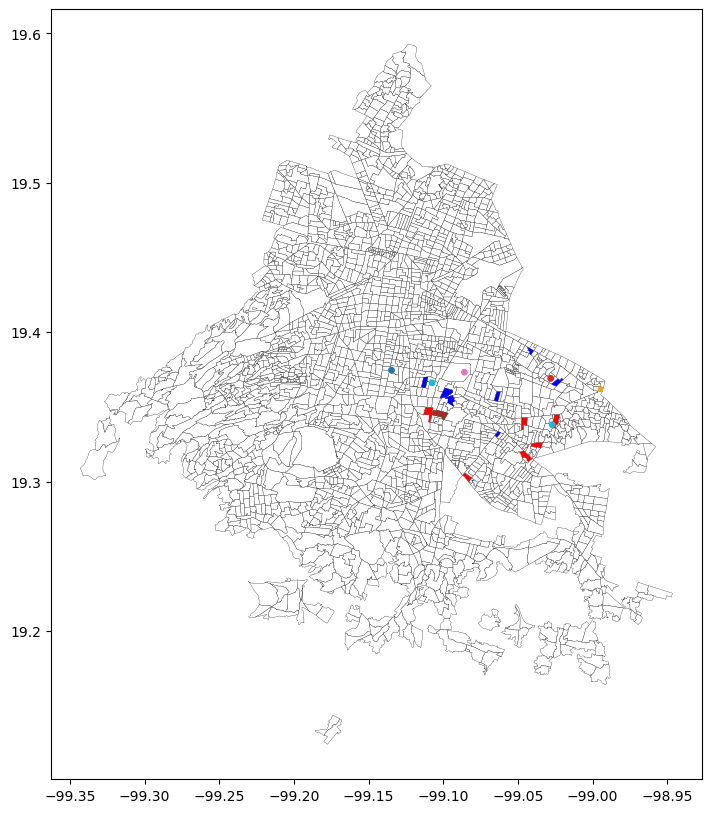

In [262]:
# Annotation: Overlay polygon groups 1–5 with remaining points.
fig,ax=plt.subplots(figsize=(12,10))
alcal.plot(ax=ax,color='white',edgecolor='black',linewidth=0.2)
alcgrupo2.plot(ax=ax,color='blue')
alcgrupo1.plot(ax=ax,color='red')
alcgrupo3.plot(ax=ax,color='orange')
alcgrupo4.plot(ax=ax,color='green')
alcgrupo5.plot(ax=ax,color='brown')
dftest9.plot(ax=ax,column='pobreza',markersize=15,categorical=True)

In [263]:
# Annotation: Inspect poverty categories represented in group 5.
grupo['pobreza'].unique()

array(['(18, 34]'], dtype=object)

In [264]:
# Annotation: Mark group-5 AGEBs in the socioeconomic polygon layer.
listag=grupo['CVE'].values.tolist()

alcshppob['grupo']=''

for ageb in listag:
    # Asignar el valor 1 en 'grupo' para las filas que tienen 'CVE_AGEB_x' igual a ageb y 'alcaldia_hechos' igual a alcaldia
    alcshppob.loc[(alcshppob['CVEGEO'] == ageb), 'grupo'] = 5
    
    


alcshppob[alcshppob['grupo']==5]['Rango de pobreza (%)'].unique()

array(['(18, 34]'], dtype=object)

In [265]:
# Annotation: Extract numeric group identifiers for Queen expansion of group 5.
gruposcat=alcshppob.grupo.unique()
gruposcat = [x for x in gruposcat if isinstance(x, (int, float))]
gruposcat

[5]

In [266]:
# Annotation: Apply the Queen-neighbour extension to group 5.

agpobtlafveci5 = obtener_poligonos_vecinos_extendidos(alcshppob, w_queen, gruposcat)

C:\Users\Luis Vilches\AppData\Local\Temp\ipykernel_1828\828583937.py:50: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  fags = pd.concat([fags, dif])


In [267]:
# Annotation: Inspect expanded group-5 polygons.
agpobtlafveci5

,CVEGEO,CVE_ENT,CVE_MUN_x,CVE_LOC,CVE_AGEB_x,geometry,Unnamed: 0,Clave de entidad,Entidad \nfederativa,CVE_MUN_y,Municipio,Rango de pobreza (%),Rango de pobreza extrema (%),CVE_AGEB_y,Clave localidad,grupo
906,0900700010483,09,007,0001,0483,"POLYGON ((-99.13057 19.37711, -99.13020 19.377...",744,9,Ciudad de México,007,Iztapalapa,"(18, 34]","[ 0, 20]",0483,1,5
907,0900700010498,09,007,0001,0498,"POLYGON ((-99.12991 19.37131, -99.12991 19.371...",745,9,Ciudad de México,007,Iztapalapa,"(18, 34]","[ 0, 20]",0498,1,5


In [268]:
# Annotation: Convert expanded group-5 polygons to a GeoDataFrame.
agpobtlafveci5=gpd.GeoDataFrame(agpobtlafveci5,geometry=agpobtlafveci5.geometry)

In [269]:
# Annotation: Inspect poverty ranges in expanded group-5 polygons.
agpobtlafveci5['Rango de pobreza (%)'].unique()

array(['(18, 34]'], dtype=object)

<Axes: >

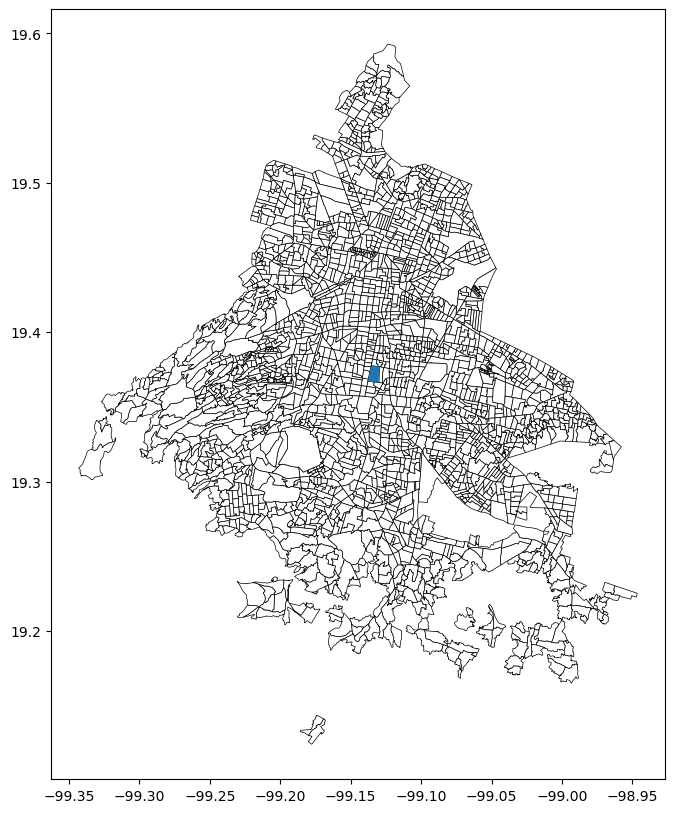

In [270]:
# Annotation: Map the Queen-expanded polygons for group 5.
fig,ax=plt.subplots(figsize=(12,10))
alcshppob.plot(ax=ax,color='white',edgecolor='black',linewidth=0.5)
#agpobtlafveci.plot(ax=ax,column='Qpob',legend=True,cmap='viridis')
#agpobtlafveci.plot(ax=ax,column='cluster',legend=True,cmap='viridis')
agpobtlafveci5.plot(ax=ax)

## 17. Exploratory group 6

The sixth group follows the same pattern. The root-removal condition compares geometry to a poverty string, and the polygon-construction cells again reuse `alcgrupo4`; therefore, the stored group-6 polygon layer is not an independent result.


In [271]:
# Annotation: Count poverty categories remaining before constructing group 6.
dftest11['pobreza'].value_counts()

pobreza
[ 0, 18]     2
(50, 70]     1
(70, 100]    1
Name: count, dtype: int64

In [272]:
# Annotation: Select a seed for group 6.
central_point = find_central_point_by_community(dftest11, dist_matrix_df)
print("Punto central:", central_point)



Índices con el valor máximo: ['0900700010604' '0900700010727' '0900700012475' '0900700015003']
Punto central: geometry    POINT (-99.1075050885205 19.3660703371296)
pobreza                                       [ 0, 18]
CVE                                      0900700010727
IDS                                                  9
Name: 9, dtype: object


C:\ProgramData\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\ProgramData\anaconda3\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\ProgramData\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\ProgramData\anaconda3\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\ProgramData\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\ProgramData\anaconda3\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Program

In [273]:
# Annotation: Convert the seed Series positionally into geometry and poverty values.
central_point=[central_point[0],central_point[1]]
central_point

C:\Users\Luis Vilches\AppData\Local\Temp\ipykernel_1828\610654960.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  central_point=[central_point[0],central_point[1]]


[<POINT (-99.108 19.366)>, '[ 0, 18]']

In [274]:
# Annotation: Select the group-6 root by geometry.
root=dftest11[dftest11['geometry']==central_point[0]]
root

,geometry,pobreza,CVE,IDS
9,POINT (-99.10751 19.36607),"[ 0, 18]",0900700010727,9


<Axes: >

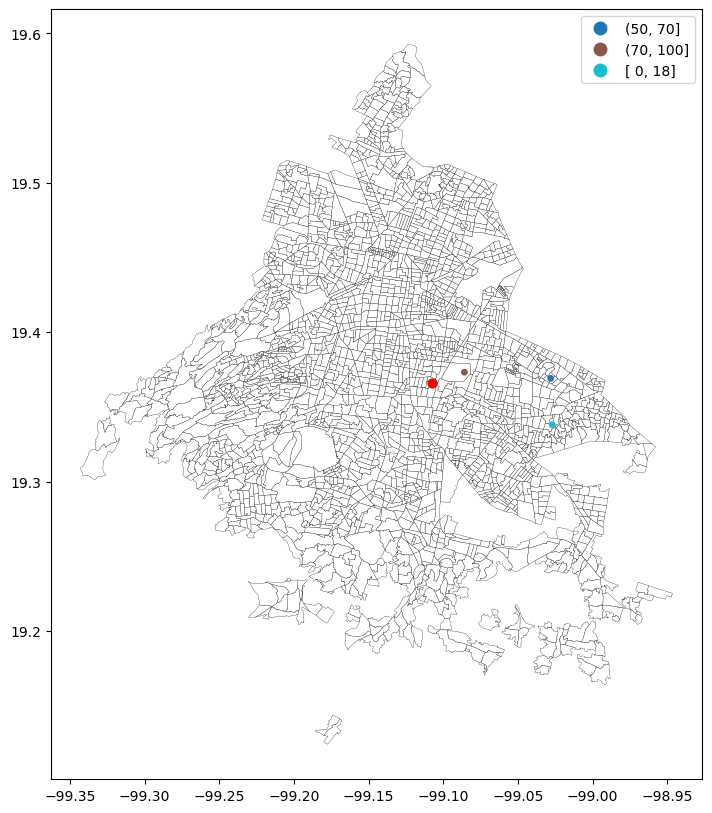

In [275]:
# Annotation: Map the group-6 root over remaining points.
fig,ax=plt.subplots(figsize=(12,10))
alcal.plot(ax=ax,color='white',edgecolor='black',linewidth=0.2)
dftest11.plot(ax=ax,column='pobreza',markersize=15,legend=True,categorical=True)
root.plot(ax=ax,markersize=40,color='red')


In [276]:
# Annotation: Initialize the group-6 GeoDataFrame.
grupo=gpd.GeoDataFrame(root,geometry=root.geometry)
grupo.columns

Index(['geometry', 'pobreza', 'CVE', 'IDS'], dtype='object')

In [277]:
# Annotation: Inspect the group-6 root poverty category.
grupo['pobreza']

9    [ 0, 18]
Name: pobreza, dtype: object

In [278]:
# Annotation: Display the previously stored poverty-category list.
listapobreza

['(34, 50]']

In [279]:
# Annotation: Attempt to remove the root by comparing geometry with a poverty-category string.
dftest12=dftest11[dftest11['geometry'] != central_point[1]]
dftest12

,geometry,pobreza,CVE,IDS
4,POINT (-99.02814 19.36908),"(50, 70]",0900700010604,4
9,POINT (-99.10751 19.36607),"[ 0, 18]",0900700010727,9
18,POINT (-99.02713 19.33807),"[ 0, 18]",0900700015003,18
19,POINT (-99.08589 19.37319),"(70, 100]",0900700012475,19


In [280]:
# Annotation: Expand group 6 using equal poverty and the mean-distance threshold.
import pandas as pd

# Supongamos que tienes los DataFrames dftest2 y grupo, y la matriz de distancias dist_matrix_df ya definidos
# También asumiendo que lim_inf_pob, lim_sup_pob, y mean_distance ya están definidos


# Itera sobre las filas de dftest2
for i in range(len(dftest12)):
    row2 = dftest12.iloc[i]
    ind2 = row2['IDS']
    #pob2 = row2['poblacion']
    rangpob2 = row2['pobreza']
    
    for j in range(len(grupo)):
        row1 = grupo.iloc[j]
        ind1 = row1['IDS']
        #pob1 = row1['poblacion']
        rangpob = row1['pobreza']
        
        distance_value = dist_matrix_df.loc[ind1, ind2]
        if (distance_value <= mean_distance) and (rangpob == rangpob2):
            
            grupo = pd.concat([grupo, pd.DataFrame([row2])], ignore_index=True)
            break  # Salir del bucle interno después de agregar la fila

print(grupo)



                     geometry   pobreza            CVE  IDS
0  POINT (-99.10751 19.36607)  [ 0, 18]  0900700010727    9
1  POINT (-99.10751 19.36607)  [ 0, 18]  0900700010727    9


In [281]:
# Annotation: Inspect poverty categories represented in group 6.
grupo['pobreza'].unique()

array(['[ 0, 18]'], dtype=object)

In [282]:
# Annotation: Store group-6 identifiers and report group size.
listaids=grupo['IDS'].values.tolist()
len(grupo)

2

In [283]:
# Annotation: Remove group-6 members from the remaining candidates.
dftest13 = dftest12[~dftest12['IDS'].isin(listaids)]
dftest13['pobreza'].unique()

array(['(50, 70]', '[ 0, 18]', '(70, 100]'], dtype=object)

In [284]:
# Annotation: Report the final size of group 6.
len(grupo)

2

<Axes: >

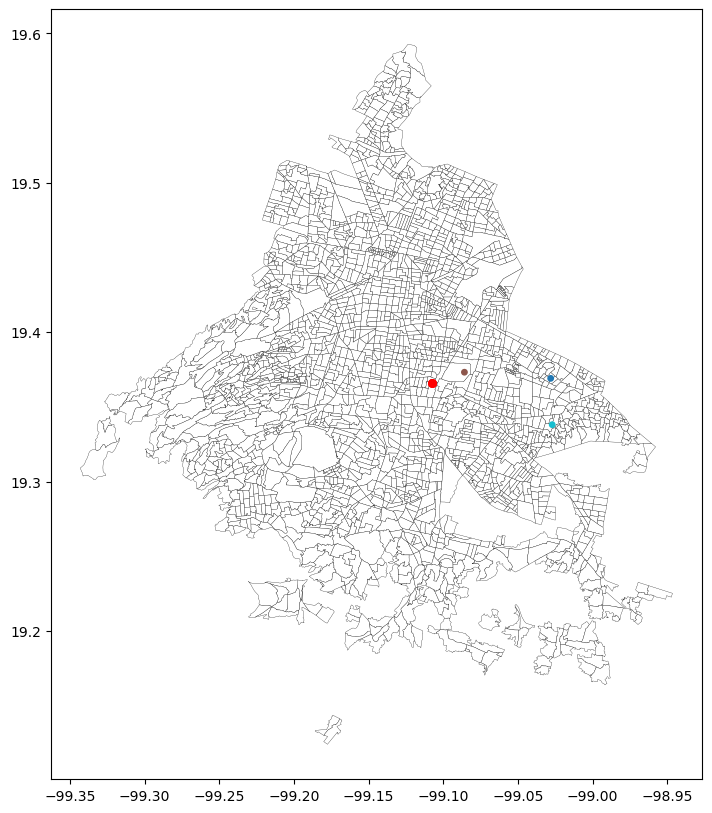

In [285]:
# Annotation: Map group 6 and remaining points.
fig,ax=plt.subplots(figsize=(12,10))
alcal.plot(ax=ax,color='white',edgecolor='black',linewidth=0.2)
grupo.plot(ax=ax,markersize=30,color='red')

dftest13.plot(ax=ax,column='pobreza',markersize=15,categorical=True)

In [286]:
# Annotation: Assign label 6 to the sixth exploratory group.
grupo['newgroup']=6

In [287]:
# Annotation: Attempt to create group-6 polygons but concatenate and reconvert group-4 objects.
# Crear un DataFrame vacío para almacenar los resultados
alcgrupo6= gpd.GeoDataFrame()

# Lista de IDs de ageb y valores de cluster de grupo
agsgru = grupo.CVE.values.tolist()
lista_cluster = grupo.newgroup.values.tolist()

# Asignar el valor del cluster a alcshp
filas_a_agregar = []
for i in range(len(alcal)):
    row2 = alcal.iloc[i]
    if row2.CVEGEO in agsgru:
        # Obtener el valor del cluster correspondiente a la ageb de alcshp
        cluster_value = lista_cluster[agsgru.index(row2.CVEGEO)]
        # Asignar el valor del cluster a la columna 'cluster' en alcshp
        row2['cluster'] = cluster_value
        # Agregar la fila a la lista de filas a agregar
        filas_a_agregar.append(row2)

# Concatenar las filas a agregar al DataFrame alcgrupo1
alcgrupo6 = pd.concat([alcgrupo4, pd.DataFrame(filas_a_agregar)], ignore_index=True)

# Mostrar el resultado
alcgrupo6=gpd.GeoDataFrame(alcgrupo4,geometry=alcgrupo4.geometry)

C:\Users\Luis Vilches\AppData\Local\Temp\ipykernel_1828\3896824988.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  row2['cluster'] = cluster_value


In [288]:
# Annotation: Propagate labels by iterating over group-4 polygons instead of group 6.
# Crear una columna 'cluster' en alcshp
alcal['cluster'] = ''

# Iterar sobre cada fila de alcgrupo1
for i in range(len(alcgrupo4)):
    row = alcgrupo4.iloc[i]
    ageb = row['CVEGEO']
    cluster_value = row['cluster']
    
    # Buscar la fila correspondiente en alcshp y asignar el valor del cluster
    alcal.loc[alcal['CVEGEO'] == ageb, 'cluster'] = cluster_value


<Axes: >

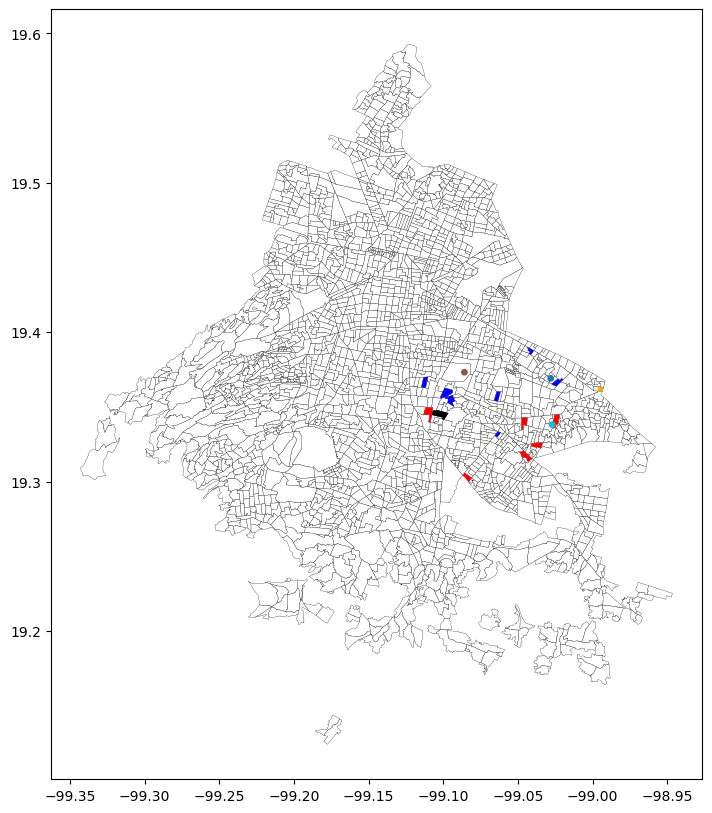

In [289]:
# Annotation: Overlay polygon groups 1–6 with remaining points.
fig,ax=plt.subplots(figsize=(12,10))
alcal.plot(ax=ax,color='white',edgecolor='black',linewidth=0.2)
alcgrupo2.plot(ax=ax,color='blue')
alcgrupo1.plot(ax=ax,color='red')
alcgrupo3.plot(ax=ax,color='orange')
alcgrupo4.plot(ax=ax,color='green')
alcgrupo5.plot(ax=ax,color='brown')
alcgrupo6.plot(ax=ax,color='black')
dftest13.plot(ax=ax,column='pobreza',markersize=15,categorical=True)

In [290]:
# Annotation: Inspect poverty categories represented in group 6.
grupo['pobreza'].unique()

array(['[ 0, 18]'], dtype=object)

In [291]:
# Annotation: Mark group-6 AGEBs in the socioeconomic polygon layer.
listag=grupo['CVE'].values.tolist()

alcshppob['grupo']=''

for ageb in listag:
    # Asignar el valor 1 en 'grupo' para las filas que tienen 'CVE_AGEB_x' igual a ageb y 'alcaldia_hechos' igual a alcaldia
    alcshppob.loc[(alcshppob['CVEGEO'] == ageb), 'grupo'] = 6
    
    


alcshppob[alcshppob['grupo']==6]['Rango de pobreza (%)'].unique()

array(['[ 0, 18]'], dtype=object)

In [292]:
# Annotation: Extract numeric group identifiers for Queen expansion of group 6.
gruposcat=alcshppob.grupo.unique()
gruposcat = [x for x in gruposcat if isinstance(x, (int, float))]
gruposcat

[6]

In [293]:
# Annotation: Apply the Queen-neighbour extension to group 6.

agpobtlafveci6 = obtener_poligonos_vecinos_extendidos(alcshppob, w_queen, gruposcat)

C:\Users\Luis Vilches\AppData\Local\Temp\ipykernel_1828\828583937.py:50: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  fags = pd.concat([fags, dif])


In [294]:
# Annotation: Inspect expanded group-6 polygons.
agpobtlafveci6

,CVEGEO,CVE_ENT,CVE_MUN_x,CVE_LOC,CVE_AGEB_x,geometry,Unnamed: 0,Clave de entidad,Entidad \nfederativa,CVE_MUN_y,Municipio,Rango de pobreza (%),Rango de pobreza extrema (%),CVE_AGEB_y,Clave localidad,grupo
883,0900700010727,09,007,0001,0727,"POLYGON ((-99.10576 19.36717, -99.10514 19.366...",764,9,Ciudad de México,007,Iztapalapa,"[ 0, 18]","[ 0, 20]",0727,1,6
1121,0900700015446,09,007,0001,5446,"POLYGON ((-99.10514 19.36874, -99.10576 19.367...",1114,9,Ciudad de México,007,Iztapalapa,"[ 0, 18]","[ 0, 20]",5446,1,6
948,0900700010958,09,007,0001,0958,"POLYGON ((-99.11525 19.35694, -99.11477 19.358...",784,9,Ciudad de México,007,Iztapalapa,"[ 0, 18]","[ 0, 20]",0958,1,6
860,0900700011180,09,007,0001,1180,"POLYGON ((-99.11525 19.35694, -99.11469 19.356...",801,9,Ciudad de México,007,Iztapalapa,"[ 0, 18]","[ 0, 20]",1180,1,6
861,0900700011195,09,007,0001,1195,"POLYGON ((-99.10715 19.35622, -99.10715 19.356...",802,9,Ciudad de México,007,Iztapalapa,"[ 0, 18]","[ 0, 20]",1195,1,6


In [295]:
# Annotation: Convert expanded group-6 polygons to a GeoDataFrame.
agpobtlafveci6=gpd.GeoDataFrame(agpobtlafveci6,geometry=agpobtlafveci6.geometry)

In [296]:
# Annotation: Inspect poverty ranges in expanded group-6 polygons.
agpobtlafveci6['Rango de pobreza (%)'].unique()

array(['[ 0, 18]'], dtype=object)

## 18. Combine polygon groups

The point-derived AGEB layers and Queen-expanded layers are concatenated for final inspection. Because groups 5 and 6 are built from group-4 objects in the preserved code, the combined polygon output requires correction before quantitative use.


In [297]:
# Annotation: Concatenate the six Queen-expanded polygon layers.
agpob=pd.concat([agpobtlafveci,agpobtlafveci2,agpobtlafveci3,agpobtlafveci4,
                agpobtlafveci5,agpobtlafveci6])

In [304]:
# Annotation: Concatenate the six core AGEB polygon layers.
original=pd.concat([alcgrupo1,alcgrupo2,alcgrupo3,alcgrupo4,alcgrupo5,alcgrupo6])

In [354]:
# Annotation: Inspect the stored group-6 polygon object.
alcgrupo6

,CVEGEO,POBREZA,POBREZAEX,ID,geometry,cluster
0,0900700011388,"(34, 50]","[ 0, 20]",818,"POLYGON ((-99.10246 19.34732, -99.10225 19.347...",4


## 19. Final diagnostic map

The final map overlays the six core polygon groups and their poverty-matched Queen neighbours over Iztapalapa. This is an exploratory cartographic product rather than the direct DBSCAN partition map.


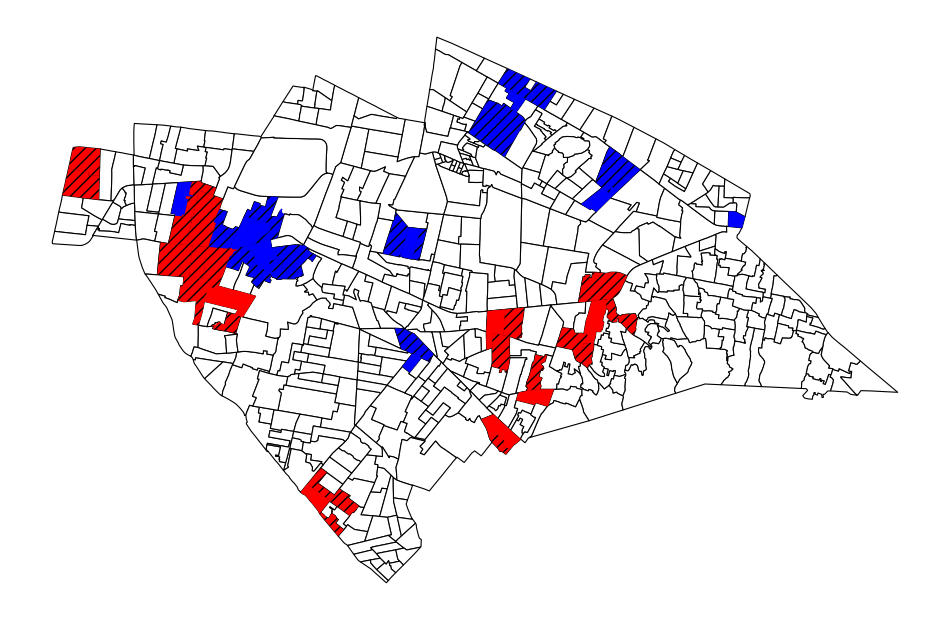

In [356]:
# Annotation: Create and save the final diagnostic map of core and Queen-expanded groups.
fig,ax=plt.subplots(figsize=(12,10))
alcalizt.plot(ax=ax,color='white',edgecolor='black',linewidth=0.8)
agpobtlafveci.plot(ax=ax,color='red',hatch='///')
alcgrupo1.plot(ax=ax,color='red')

agpobtlafveci2.plot(ax=ax,color='blue',hatch='///')
alcgrupo2.plot(ax=ax,color='blue')

agpobtlafveci3.plot(ax=ax,color='blue',hatch='///')
alcgrupo3.plot(ax=ax,color='blue')

agpobtlafveci4.plot(ax=ax,color='red',hatch='///')
alcgrupo4.plot(ax=ax,color='red')

agpobtlafveci5.plot(ax=ax,color='red',hatch='///')
alcgrupo5.plot(ax=ax,color='red')

agpobtlafveci6.plot(ax=ax,color='red',hatch='///')
alcgrupo6.plot(ax=ax,color='red')
ax.set_xticks([])  # Quita los ticks del eje X
ax.set_yticks([])  # Quita los ticks del eje Y
ax.set_frame_on(False)  # Elimina el marco alrededor del gráfico

plt.savefig("mapa_por_cluster1_7.jpg", format='jpg', dpi=300, bbox_inches='tight')

In [756]:
# Annotation: Inspect the incident points remaining after the six grouping passes.
dftest13

,geometry,pobreza,CVE,IDS
55,POINT (-99.05046 19.31869),"(50, 70]",0900700012051,55
72,POINT (-99.18814 19.25995),"(34, 50]",0901200011744,72
